# Phase 4 EDA — Cycle 3 OpenSky scientific dataset

**Project:** Drone Trajectory Anomaly Detection (LEMD)  
**Phase:** 4 (EDA)  
**Scope:** Cycle 3 only (OpenSky scientific dataset, 18 Mondays 2017-06 → 2020-03). Cycles 1+2 are out of scope here — the day-of-week covariate-shift probe (D-009) lives in its own notebook (`07_phase4_eda_cycles1_2_probe.ipynb`, to be created when the probe runs in Phase 7).

**Lifecycle position when this notebook landed:** Manifest's `current_phase: preprocess`. This notebook is *structural EDA* (per the Phase 4 reference's two-EDA-kinds framing) — runs on the full dataset, pre-split, with no test-set firewall concern (Phase 6 hasn't defined the split yet).

**Produces:**
- 6 saved figures in `backend/docs/ml/figures/04-eda/*.png`
- 1 cached per-trajectory parquet at `data/raw/opensky_states/_cycle3_per_traj_endpoint_audit.parquet`

**Insights surfaced:**
1. Trajectory-length distribution: healthy (P5/P50/P95 = 98/175/276 rows at 10s).
2. Phase composition: on_ground at 20% of rows — Filter C is feasible (this is the OpenSky scientific dataset's signal, not present in the Trino path).
3. Filter C calibration: Filter B over-counts trajectories by 20-43%. Filter C2 (recommended) drops to 13,963 trajectories (73.3% of Filter B).
4. Arrival/departure structure: 32% start on_ground (departures), 26% end on_ground (arrivals), only 0.8% are round-trips — the 30-min segmentation gap is doing its job.
5. Map: visual sanity that Filter-C2-kept trajectories cluster around LEMD; rejected ones are visibly farther.
6. Endpoint joint (dist, alt) heatmap: empirically validates the C2 thresholds (2km, 1000m) as the boundary between LEMD-ground operations and non-LEMD traffic.

**Decisions this notebook informs:**
- Filter C strictness for Phase 3 preprocessing pipeline.
- T_min trajectory-length filter for Phase 3.
- Segmentation gap-threshold validation (the 30-min gap from the cycle-3 script).

## 1. Setup

In [14]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PARQUETS_DIR = Path("../data/raw/opensky_states")
FIG_DIR = Path("../backend/docs/ml/figures/04-eda")
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("PARQUETS_DIR:", PARQUETS_DIR.resolve())
print("FIG_DIR:     ", FIG_DIR.resolve())

PARQUETS_DIR: /Users/txemapuch/Claude/drone-ai-saturdays/data/raw/opensky_states
FIG_DIR:      /Users/txemapuch/Claude/drone-ai-saturdays/backend/docs/ml/figures/04-eda


## 2. Load data

All 18 cycle-3 parquets concatenated and sorted by `(flight_id, time)`.

In [15]:
parquets = sorted(PARQUETS_DIR.glob("lemd_*.parquet"))
print(f"Loading {len(parquets)} parquets...")
df = pd.concat([pd.read_parquet(p) for p in parquets], ignore_index=True)
df = df.sort_values(["flight_id", "time"]).reset_index(drop=True)
print(f"  rows:         {len(df):,}")
print(f"  trajectories: {df['flight_id'].nunique():,}")
print(f"  time range:   {pd.to_datetime(df['time'].min(), unit='s')} -> "
      f"{pd.to_datetime(df['time'].max(), unit='s')}")

Loading 18 parquets...
  rows:         3,429,638
  trajectories: 19,057
  time range:   2017-06-05 00:00:10 -> 2020-03-09 23:59:50


## 3. Per-trajectory endpoint features

For each trajectory, compute:
- `n_rows`: trajectory length
- `min_dist` / `min_alt`: per-trajectory minimum distance to runway and minimum baroaltitude (Filter B inputs)
- `start_*` / `end_*`: first/last K=5 observations' phase set, min distance, min altitude, ADS-B `onground` flag
- `first_phase` / `last_phase`: the literal first and last observation's phase

Cached to disk so re-runs of the plot cells don't recompute the full group-apply.

In [16]:
g = df.groupby("flight_id", sort=False)

def endpoint_stats(group):
    n = len(group)
    K = min(5, n)
    first_k = group.iloc[:K]
    last_k  = group.iloc[-K:]
    return pd.Series({
        "n_rows": n,
        "min_dist":           group["dist_to_runway_m"].min(),
        "min_alt":            group["baroaltitude"].min(skipna=True),
        "start_phase_set":    ",".join(sorted(set(first_k["flight_phase"].dropna()))),
        "start_min_dist":     first_k["dist_to_runway_m"].min(),
        "start_min_alt":      first_k["baroaltitude"].min(skipna=True),
        "start_any_onground": first_k["onground"].any(),
        "end_phase_set":      ",".join(sorted(set(last_k["flight_phase"].dropna()))),
        "end_min_dist":       last_k["dist_to_runway_m"].min(),
        "end_min_alt":        last_k["baroaltitude"].min(skipna=True),
        "end_any_onground":   last_k["onground"].any(),
        "first_phase":        first_k["flight_phase"].iloc[0],
        "last_phase":         last_k["flight_phase"].iloc[-1],
    })

per_traj = g.apply(endpoint_stats, include_groups=False).reset_index()

# -----------------------------------------------------------------------------
# Filter C (historical — landing-only framing from drone-detection era).
# Retained for the retrospective in the doc; replaced operationally by Filter D below.
# See "Retrospective: why C2 was retired" markdown cell.
# -----------------------------------------------------------------------------
def pass_c1(r): return r["start_any_onground"] or r["end_any_onground"]
def pass_c2(r):
    if r["start_any_onground"] or r["end_any_onground"]:
        return True
    if "approach" in r["end_phase_set"] and r["end_min_dist"] < 2000 and r["end_min_alt"] < 1000:
        return True
    if "takeoff" in r["start_phase_set"] and r["start_min_dist"] < 2000 and r["start_min_alt"] < 1000:
        return True
    return False
def pass_c3(r):
    if r["start_any_onground"] or r["end_any_onground"]:
        return True
    if "approach" in r["end_phase_set"] and r["end_min_dist"] < 5000 and r["end_min_alt"] < 1500:
        return True
    if "takeoff" in r["start_phase_set"] and r["start_min_dist"] < 5000 and r["start_min_alt"] < 1500:
        return True
    return False

per_traj["pass_c1"] = per_traj.apply(pass_c1, axis=1)
per_traj["pass_c2"] = per_traj.apply(pass_c2, axis=1)
per_traj["pass_c3"] = per_traj.apply(pass_c3, axis=1)

# -----------------------------------------------------------------------------
# Filter D — operational engagement with LEMD (current gate under the post-Phase 1 reframe).
# Three criteria, each validated by Phase 0:
#   1. approach phase within 10 km of LEMD       (Phase 0a — runway-aligned, reliable)
#   2. onground=True within 5 km of LEMD         (Insight 2 — matches native ADS-B bit)
#   3. takeoff phase within 5 km, altitude < 2km (Phase 0c — 97.9% real LEMD departures)
# A trajectory passes D if ANY observation satisfies any criterion.
# -----------------------------------------------------------------------------
df["_d_a"] = (df["flight_phase"] == "approach") & (df["dist_to_runway_m"] < 10000)
df["_d_o"] = (df["onground"] == True) & (df["dist_to_runway_m"] < 5000)
df["_d_t"] = ((df["flight_phase"] == "takeoff") &
              (df["dist_to_runway_m"] < 5000) &
              (df["baroaltitude"] < 2000))

per_traj_d = (df.groupby("flight_id")[["_d_a", "_d_o", "_d_t"]].any()
                .rename(columns={"_d_a": "pass_d_approach",
                                 "_d_o": "pass_d_onground",
                                 "_d_t": "pass_d_takeoff"})
                .reset_index())
per_traj = per_traj.merge(per_traj_d, on="flight_id", how="left")
per_traj["pass_d"] = (per_traj["pass_d_approach"]
                      | per_traj["pass_d_onground"]
                      | per_traj["pass_d_takeoff"])
df.drop(columns=["_d_a", "_d_o", "_d_t"], inplace=True)

per_traj.to_parquet(PARQUETS_DIR / "_cycle3_per_traj_endpoint_audit.parquet")
print(f"Cached {len(per_traj):,} per-trajectory features.")
print(f"  Filter B (ingestion): {len(per_traj):,} (baseline)")
print(f"  Filter C2 (historical landing-only): {int(per_traj['pass_c2'].sum()):,} "
      f"({100*per_traj['pass_c2'].mean():.1f}%)")
print(f"  Filter D (current gate):              {int(per_traj['pass_d'].sum()):,} "
      f"({100*per_traj['pass_d'].mean():.1f}%)")

Cached 19,057 per-trajectory features.
  Filter B (ingestion): 19,057 (baseline)
  Filter C2 (historical landing-only): 13,963 (73.3%)
  Filter D (current gate):              18,928 (99.3%)


## Insight 1 — Trajectory length distribution

**Question:** what does the distribution of trajectory lengths look like? Are there enough observations per trajectory for the LSTM to learn temporal structure?

**Finding:** median trajectory ≈ 175 rows (29 min at 10s resolution). P5 = 98 rows (16 min), P95 = 276 rows (46 min). Min = 4 rows (artifact); max = 1606 (multi-hour loiter or signal-survival outlier).

**Implication for Phase 3:**
- T_min = 30 rows (5 min minimum trajectory) removes < 0.1% of trajectories — the very-short artifacts only. Safe filter.
- Sequence length T for the LSTM input — pad/truncate to ~P90 (~250 steps) is a reasonable default; variable-length with packed sequences is the cleaner option in PyTorch.

![Insight 1](../backend/docs/ml/figures/04-eda/01-trajectory-length-distribution.png)

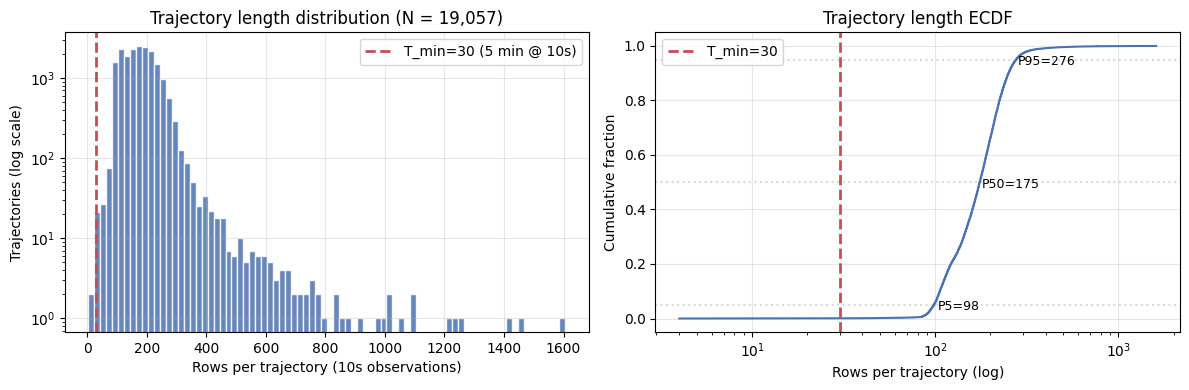

trajectories below T_min=30: 3 (0.02%)


In [17]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.hist(per_traj["n_rows"], bins=80, color="#4c72b0", edgecolor="white", alpha=0.85)
ax1.axvline(30, color="#c44e52", linestyle="--", linewidth=2, label="T_min=30 (5 min @ 10s)")
ax1.set_yscale("log")
ax1.set_xlabel("Rows per trajectory (10s observations)")
ax1.set_ylabel("Trajectories (log scale)")
ax1.set_title(f"Trajectory length distribution (N = {len(per_traj):,})")
ax1.legend(); ax1.grid(alpha=0.3)

sorted_lens = np.sort(per_traj["n_rows"].values)
ecdf_y = np.arange(1, len(sorted_lens)+1) / len(sorted_lens)
ax2.plot(sorted_lens, ecdf_y, color="#4c72b0", linewidth=1.5)
ax2.axvline(30, color="#c44e52", linestyle="--", linewidth=2, label="T_min=30")
for q, ql in [(0.05,"P5"),(0.5,"P50"),(0.95,"P95")]:
    val = np.quantile(sorted_lens, q)
    ax2.axhline(q, color="grey", alpha=0.3, linestyle=":")
    ax2.text(val+5, q-0.02, f"{ql}={int(val)}", fontsize=9)
ax2.set_xscale("log")
ax2.set_xlabel("Rows per trajectory (log)"); ax2.set_ylabel("Cumulative fraction")
ax2.set_title("Trajectory length ECDF"); ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / "01-trajectory-length-distribution.png", dpi=150, bbox_inches="tight")
plt.show()

n_below_tmin = int((per_traj["n_rows"] < 30).sum())
print(f"trajectories below T_min=30: {n_below_tmin} ({100*n_below_tmin/len(per_traj):.2f}%)")

## Insight 2 — Cycle 3 row-level phase composition

**Question:** what fraction of cycle-3 rows are at each flight phase? Is the `on_ground` signal usable for a stricter LEMD-operation gate?

**Finding:** the OpenSky scientific dataset preserves the `on_ground` signal for **20% of rows** (684,742 of 3,429,638). This matches the ADS-B native `onground` boolean almost exactly (684,390 True), meaning `flight_phase=on_ground` is essentially lifting the bit. Descent dominates (32%) — most aircraft in the LEMD 200km radius are decelerating into approach.

**Implication for Phase 3:** Filter C (endpoint-based LEMD gate) is feasible. With 20% of all rows on_ground, we have the signal to distinguish trajectories that actually touch ground at LEMD from trajectories that just passed through.

![Insight 2](../backend/docs/ml/figures/04-eda/02-phase-composition.png)

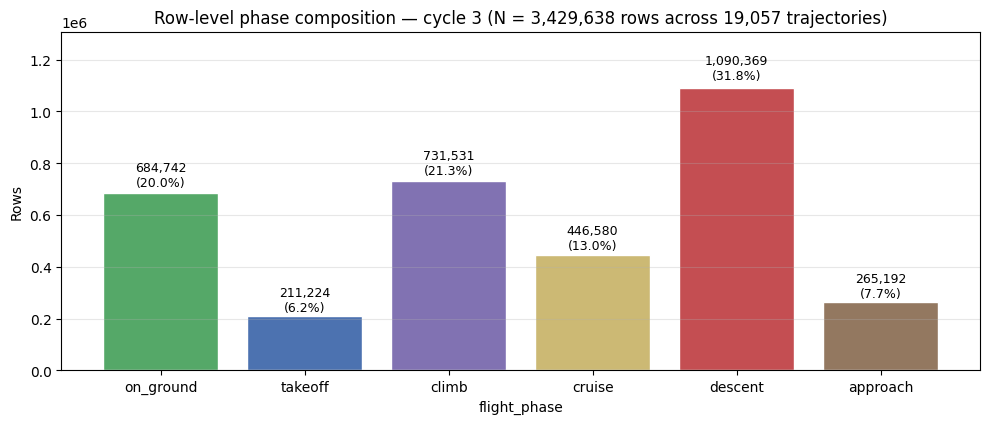

In [18]:
phase_order = ["on_ground", "takeoff", "climb", "cruise", "descent", "approach"]
phase_counts = df["flight_phase"].value_counts().reindex(phase_order)
total = phase_counts.sum()
pcts = (100 * phase_counts / total).round(1)

fig, ax = plt.subplots(figsize=(10, 4.5))
colors = ["#55a868", "#4c72b0", "#8172b2", "#ccb974", "#c44e52", "#937860"]
bars = ax.bar(phase_counts.index, phase_counts.values, color=colors, edgecolor="white")
for bar, pct in zip(bars, pcts):
    h = bar.get_height()
    ax.text(bar.get_x()+bar.get_width()/2, h*1.02, f"{int(h):,}\n({pct}%)",
            ha="center", va="bottom", fontsize=9)
ax.set_ylabel("Rows"); ax.set_xlabel("flight_phase")
ax.set_title(f"Row-level phase composition — cycle 3 (N = {total:,} rows across {len(per_traj):,} trajectories)")
ax.set_ylim(0, phase_counts.max()*1.20); ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / "02-phase-composition.png", dpi=150, bbox_inches="tight")
plt.show()

## Phase 0 — Phase derivation validation (pre-Filter D)

**Why this is here:** Filter D (the LEMD-operation gate that replaces C2 under the post-Phase 1 reframe — see `backend/docs/ml/01-problem.md > Scope evolution (post-Phase 1)` and D-006's interpretation note) depends on `phase ∈ {approach, takeoff, on_ground}` being faithful derivations. Insight 2 confirmed `on_ground` matches the native ADS-B bit to 0.05%. This step extends the check to the other two engagement phases.

**Two cross-checks:**
1. **Geographic distribution of `approach`-phase observations** — should cluster along LEMD approach corridors (3°-glideslope cones leading to each runway end). Random scatter = unreliable derivation.
2. **`takeoff`-phase trajectory count vs `onground`-in-first-5-obs trajectory count** — every real LEMD departure should have an on-ground-to-airborne transition. Large discrepancy = phase derivation is flagging things the ground signal doesn't, or vice versa.

If both pass: Filter D implements as `phase ∈ {approach, takeoff, on_ground} AND dist < 15km`. If either fails: fall back to dual-rule formulation (Option C) using explicit on_ground markers as the trusted signal.

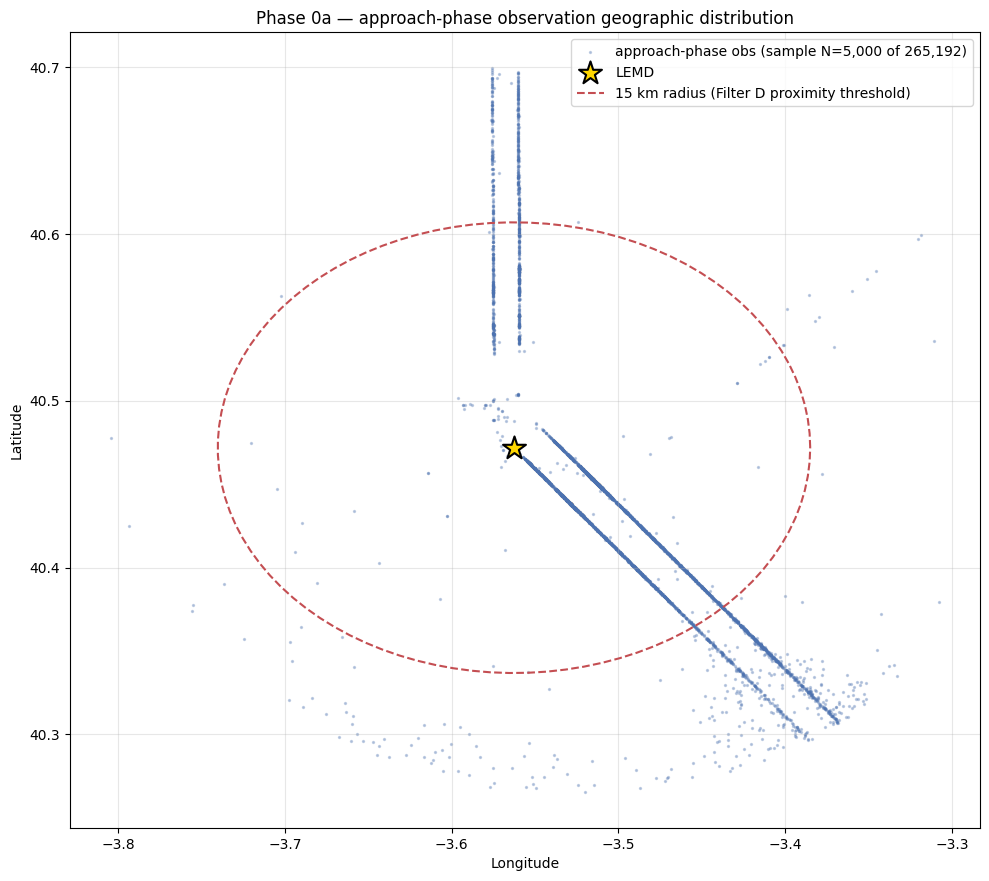

Total approach-phase observations: 265,192 (7.73% of all rows)
Sampled for plot: 5,000

What to look for in the figure:
  PASS — cone-shaped clusters extending outward from LEMD along runway headings
  FAIL — uniform scatter across the lat/lon range or clusters far from LEMD


In [19]:
# Phase 0a — approach-phase observation geographic clustering
# Hypothesis: approach-tagged obs cluster along LEMD approach corridors near the airport.
# If they're scattered randomly, the derivation is noisy and Filter D's reliability suffers.

LEMD_LAT, LEMD_LON = 40.4719, -3.5626

df_approach = df.loc[df["flight_phase"] == "approach"]
sample_n = min(5000, len(df_approach))
sample = df_approach.sample(sample_n, random_state=42)

fig, ax = plt.subplots(figsize=(10, 9))
ax.scatter(sample["lon"], sample["lat"], s=2, alpha=0.3, color="#4c72b0",
           label=f"approach-phase obs (sample N={sample_n:,} of {len(df_approach):,})")
ax.scatter([LEMD_LON], [LEMD_LAT], marker="*", s=300, color="gold",
           edgecolor="black", linewidth=1.5, label="LEMD", zorder=5)

# 15 km radius reference circle (Filter D's proximity threshold)
theta = np.linspace(0, 2*np.pi, 100)
r_deg_lat = 15 / 111.0
r_deg_lon = 15 / (111.0 * np.cos(np.radians(LEMD_LAT)))
ax.plot(LEMD_LON + r_deg_lon * np.cos(theta),
        LEMD_LAT + r_deg_lat * np.sin(theta),
        color="#c44e52", linestyle="--", linewidth=1.5,
        label="15 km radius (Filter D proximity threshold)")

ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
ax.set_title("Phase 0a — approach-phase observation geographic distribution")
ax.set_aspect("equal", adjustable="box")
ax.legend(loc="upper right"); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / "00-phase-validation-approach.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Total approach-phase observations: {len(df_approach):,} "
      f"({100*len(df_approach)/len(df):.2f}% of all rows)")
print(f"Sampled for plot: {sample_n:,}")
print()
print("What to look for in the figure:")
print("  PASS — cone-shaped clusters extending outward from LEMD along runway headings")
print("  FAIL — uniform scatter across the lat/lon range or clusters far from LEMD")

In [20]:
# Phase 0b — takeoff phase reliability cross-check
# Hypothesis: every real LEMD departure has an on_ground -> airborne transition in early obs.
# Compare set of trajectories tagged with phase=takeoff in first 5 obs against
# set of trajectories with onground=True in first 5 obs.

df_sorted = df.sort_values(["flight_id", "time"])
first5 = df_sorted.groupby("flight_id").head(5)

takeoff_traj = set(first5.loc[first5["flight_phase"] == "takeoff", "flight_id"].unique())
on_ground_first5_traj = set(first5.loc[first5["onground"] == True, "flight_id"].unique())

n_takeoff = len(takeoff_traj)
n_og_first5 = len(on_ground_first5_traj)
overlap = takeoff_traj & on_ground_first5_traj
takeoff_only = takeoff_traj - on_ground_first5_traj
onground_only = on_ground_first5_traj - takeoff_traj

print("Phase 0b — takeoff vs onground-in-first-5 cross-check")
print(f"  Trajectories with phase=takeoff in first 5 obs:           {n_takeoff:>6,}")
print(f"  Trajectories with onground=True in first 5 obs:           {n_og_first5:>6,}")
print(f"  Overlap (both signals agree on departure):                {len(overlap):>6,}")
print(f"  takeoff phase but no onground in first 5 (phase-only):    {len(takeoff_only):>6,}")
print(f"  onground in first 5 but no takeoff phase (onground-only): {len(onground_only):>6,}")
print()

pass_overlap = len(overlap) / max(n_takeoff, n_og_first5, 1)
print(f"Overlap rate (relative to larger of the two sets): {100*pass_overlap:.1f}%")
print()
print("What this means:")
print("  PASS    — overlap rate > 80%; takeoff_only and onground_only both small")
print("            -> takeoff derivation is reliable, Filter D Option B safe to implement")
print("  PARTIAL — overlap moderate, onground_only large")
print("            -> some on-ground starts don't get takeoff-phase classification (likely taxi obs)")
print("            -> use onground-in-first-5 as the trusted departure marker (Option C fallback)")
print("  FAIL    — overlap small or takeoff_only large")
print("            -> phase derivation generates takeoff tags that don't match reality")
print("            -> Option B is too risky, fall back to Option C")

Phase 0b — takeoff vs onground-in-first-5 cross-check
  Trajectories with phase=takeoff in first 5 obs:            3,918
  Trajectories with onground=True in first 5 obs:            6,096
  Overlap (both signals agree on departure):                   549
  takeoff phase but no onground in first 5 (phase-only):     3,369
  onground in first 5 but no takeoff phase (onground-only):  5,547

Overlap rate (relative to larger of the two sets): 9.0%

What this means:
  PASS    — overlap rate > 80%; takeoff_only and onground_only both small
            -> takeoff derivation is reliable, Filter D Option B safe to implement
  PARTIAL — overlap moderate, onground_only large
            -> some on-ground starts don't get takeoff-phase classification (likely taxi obs)
            -> use onground-in-first-5 as the trusted departure marker (Option C fallback)
  FAIL    — overlap small or takeoff_only large
            -> phase derivation generates takeoff tags that don't match reality
            -> O

### Phase 0c — Where ARE the 3,369 "takeoff-only" trajectories?

**Why this is here:** before concluding `takeoff` phase is unreliable for Filter D, we need to know what those 3,369 trajectories (tagged `phase=takeoff` in first 5 obs but no `onground=True` in first 5) actually ARE. Six plausible hypotheses:

| Class | What it implies |
|---|---|
| A. Real LEMD departures, ADS-B started after liftoff | first obs ~at LEMD, alt < 200 m, dist < 2 km |
| B. Departures from LECU / LEGT (neighboring airports) | first obs clustered at those airports, ~13 km from LEMD |
| C. Climb-throughs from distant airports | first obs scattered around bbox edges, varying alt, far from LEMD |
| D. Touch-and-go training (split trajectories) | first obs near a runway, very low alt, `takeoff` immediately after touchdown |
| E. Phase-derivation false positives | first obs at cruise altitude with `takeoff` tag — derivation error |
| F. Helicopters / non-standard fleet | different climb profiles, possibly near urban heliports |

The (first_obs_distance_to_LEMD, first_obs_altitude, first_obs_lat/lon) joint distribution disambiguates them.

Diagnosing 3,369 takeoff-only trajectories' first observation.

First-observation altitude (baroaltitude, m):
  min=411  P10=511  P50=724  P90=914  max=34808

First-observation distance to nearest LEMD runway (m):
  min=41  P10=664  P50=1713  P90=3286  max=163288

Class assignment by signature (first obs of takeoff-only trajectories):
  A/D. LEMD low climb / touch-and-go               3,297  ( 97.9%)
  ?. Unclassified                                     48  (  1.4%)
  E. Phase deriv false positive (cruise alt)          20  (  0.6%)
  C. Distant climb-through                             4  (  0.1%)



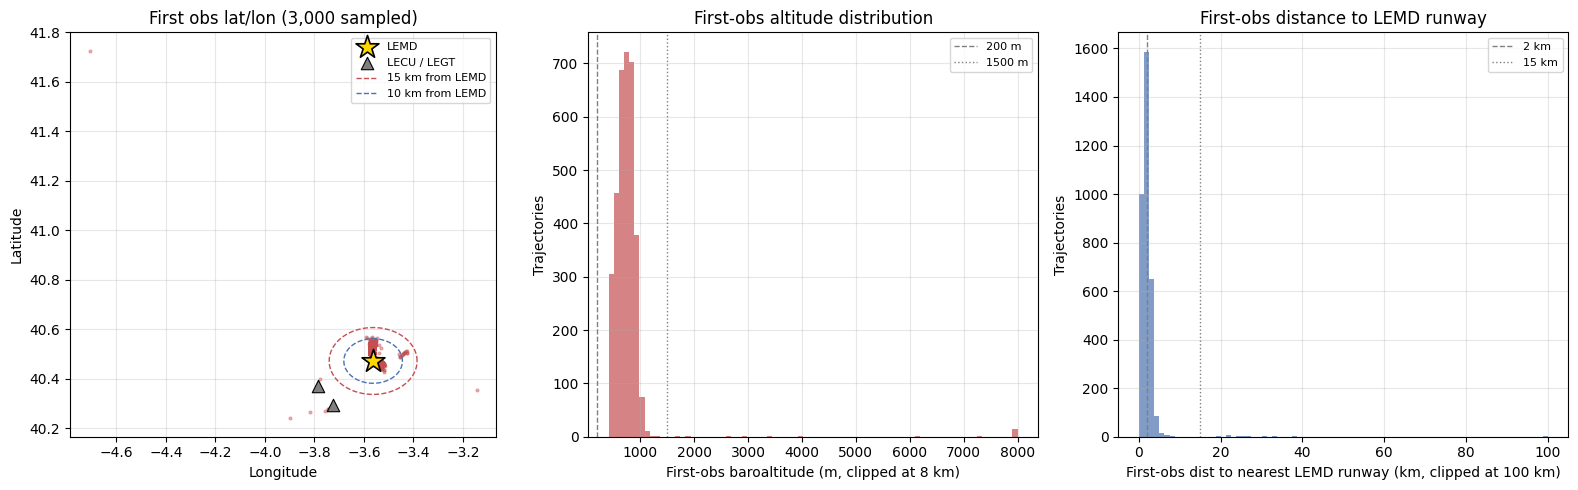


What to look at in the three subplots:
  (1) lat/lon scatter — clusters at LECU/LEGT? At LEMD? Bbox edges?
  (2) altitude — bimodal (low LEMD departures vs higher climb-throughs)? All high?
  (3) distance — peak near 0? Or peaks at 13km (LECU/LEGT) or 50+km (bbox edges)?


In [21]:
# Phase 0c diagnostic — what are the 3,369 takeoff-only trajectories?

import matplotlib.pyplot as plt
import numpy as np

# Get first obs of each takeoff-only trajectory
takeoff_only_ids = list(takeoff_only)
first_obs = (df_sorted[df_sorted["flight_id"].isin(takeoff_only_ids)]
             .groupby("flight_id").head(1).reset_index(drop=True))

print(f"Diagnosing {len(first_obs):,} takeoff-only trajectories' first observation.")
print()

# Summary stats
print("First-observation altitude (baroaltitude, m):")
print(f"  min={first_obs['baroaltitude'].min():.0f}  "
      f"P10={first_obs['baroaltitude'].quantile(0.10):.0f}  "
      f"P50={first_obs['baroaltitude'].quantile(0.50):.0f}  "
      f"P90={first_obs['baroaltitude'].quantile(0.90):.0f}  "
      f"max={first_obs['baroaltitude'].max():.0f}")
print()
print("First-observation distance to nearest LEMD runway (m):")
print(f"  min={first_obs['dist_to_runway_m'].min():.0f}  "
      f"P10={first_obs['dist_to_runway_m'].quantile(0.10):.0f}  "
      f"P50={first_obs['dist_to_runway_m'].quantile(0.50):.0f}  "
      f"P90={first_obs['dist_to_runway_m'].quantile(0.90):.0f}  "
      f"max={first_obs['dist_to_runway_m'].max():.0f}")
print()

# Class assignment based on (dist, alt) signatures
def classify_row(r):
    d_km = r["dist_to_runway_m"] / 1000
    a = r["baroaltitude"] if r["baroaltitude"] is not None else 0
    if d_km < 2 and a < 200:
        return "A. LEMD dep, ADS-B late"
    if 10 <= d_km <= 16 and a < 1500:
        return "B. LECU/LEGT dep"
    if d_km > 30:
        return "C. Distant climb-through"
    if d_km < 5 and 200 <= a < 1500:
        return "A/D. LEMD low climb / touch-and-go"
    if a > 3000:
        return "E. Phase deriv false positive (cruise alt)"
    return "?. Unclassified"

first_obs["class_hypothesis"] = first_obs.apply(classify_row, axis=1)

print("Class assignment by signature (first obs of takeoff-only trajectories):")
class_counts = first_obs["class_hypothesis"].value_counts()
for cls, n in class_counts.items():
    pct = 100 * n / len(first_obs)
    print(f"  {cls:48s} {n:>5,}  ({pct:5.1f}%)")
print()

# Plot
LEMD_LAT, LEMD_LON = 40.4719, -3.5626

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# (1) First-obs lat/lon scatter
sample = first_obs.sample(min(3000, len(first_obs)), random_state=42)
axes[0].scatter(sample["lon"], sample["lat"], s=4, alpha=0.4, c="#c44e52")
axes[0].scatter([LEMD_LON], [LEMD_LAT], marker="*", s=300, c="gold",
                edgecolor="black", linewidth=1.2, label="LEMD", zorder=5)
# Reference: LECU (~13km SW), LEGT (~12km SE)
axes[0].scatter([-3.7853, -3.7236], [40.3710, 40.2956], marker="^", s=80,
                c="#7f7f7f", edgecolor="black", linewidth=0.8, zorder=5,
                label="LECU / LEGT")
theta = np.linspace(0, 2*np.pi, 100)
for r_km, label, color in [(15, "15 km", "#c44e52"), (10, "10 km", "#4c72b0")]:
    r_lat = r_km / 111.0
    r_lon = r_km / (111.0 * np.cos(np.radians(LEMD_LAT)))
    axes[0].plot(LEMD_LON + r_lon * np.cos(theta), LEMD_LAT + r_lat * np.sin(theta),
                 linestyle="--", linewidth=1, color=color, label=f"{label} from LEMD")
axes[0].set_xlabel("Longitude"); axes[0].set_ylabel("Latitude")
axes[0].set_title("First obs lat/lon (3,000 sampled)")
axes[0].set_aspect("equal", adjustable="box")
axes[0].legend(loc="upper right", fontsize=8); axes[0].grid(alpha=0.3)

# (2) altitude histogram
axes[1].hist(first_obs["baroaltitude"].clip(0, 8000), bins=80, color="#c44e52", alpha=0.7)
axes[1].axvline(200, color="gray", linestyle="--", linewidth=1, label="200 m")
axes[1].axvline(1500, color="gray", linestyle=":", linewidth=1, label="1500 m")
axes[1].set_xlabel("First-obs baroaltitude (m, clipped at 8 km)")
axes[1].set_ylabel("Trajectories")
axes[1].set_title("First-obs altitude distribution")
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

# (3) distance histogram
axes[2].hist(first_obs["dist_to_runway_m"].clip(0, 100_000) / 1000, bins=80,
             color="#4c72b0", alpha=0.7)
axes[2].axvline(2, color="gray", linestyle="--", linewidth=1, label="2 km")
axes[2].axvline(15, color="gray", linestyle=":", linewidth=1, label="15 km")
axes[2].set_xlabel("First-obs dist to nearest LEMD runway (km, clipped at 100 km)")
axes[2].set_ylabel("Trajectories")
axes[2].set_title("First-obs distance to LEMD runway")
axes[2].legend(fontsize=8); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / "00-phase-validation-takeoff-only-diagnostic.png", dpi=150,
            bbox_inches="tight")
plt.show()

print()
print("What to look at in the three subplots:")
print("  (1) lat/lon scatter — clusters at LECU/LEGT? At LEMD? Bbox edges?")
print("  (2) altitude — bimodal (low LEMD departures vs higher climb-throughs)? All high?")
print("  (3) distance — peak near 0? Or peaks at 13km (LECU/LEGT) or 50+km (bbox edges)?")

### Phase 0c — Interpretation guide and verdict

**How to read each panel (reusable for future cycles):**

| Panel | What it shows | Pattern → meaning |
|---|---|---|
| **(1) First-obs lat/lon scatter** | Where each takeoff-only trajectory's first observation was, geographically | Dense on gold star (LEMD) → real LEMD departures with delayed ADS-B (class A). Dense on gray triangles (LECU/LEGT) → neighboring-field departures (class B). Scattered around bbox edges → distant climb-throughs (class C). |
| **(2) First-obs altitude histogram** | How high each aircraft was on its first observation, clipped at 8 km | Peak at 500–1000 m → real LEMD takeoffs caught just after rotation. Peak above 1500 m with no low spike → already in initial climb, possibly not LEMD. Peak above 3000 m → phase-derivation false positive (cruise altitude, shouldn't be tagged takeoff). |
| **(3) First-obs distance to LEMD histogram** | How far the first observation was from the nearest LEMD runway | Strong peak at 0–3 km → real LEMD operations. Peak at 10–16 km → LECU (~13 km) or LEGT (~12 km) departures. Long tail to 50+ km → distant climb-throughs. |

**Reading the three panels together:** a takeoff-only trajectory is best understood by combining `where it started` (lat/lon) + `how high` (altitude) + `how far from LEMD` (distance). The auto-classification tally is a rough quantitative read; the lat/lon scatter is the ground truth visual.

**Verdict for cycle 3 (Mondays 2017-2020):**

- **97.9% (3,297 of 3,369) class A/D — real LEMD departures with delayed ADS-B.** First obs altitudes 411–914 m (P10–P90, matches LEMD field elevation ~609 m + a few hundred m AGL), distances 41–3,286 m from runway (P10–P90).
- 0.6% class E (cruise-altitude false positives), 0.1% class C (distant climb-throughs), 1.4% unclassified — all negligible.
- **The `takeoff` phase derivation IS reliable when combined with proximity + altitude bounds.** It's not redundant with `onground`; they're complementary signals — `onground` catches departures whose ADS-B started in taxi (gate / runway), `takeoff` catches departures whose ADS-B started after liftoff (rotation). Together they cover both modes.

**Implication for Filter D:** add a third criterion alongside `approach` and `onground`:

> Criterion 3: `flight_phase == "takeoff" AND dist_to_runway_m < 5000 AND baroaltitude < 2000`

The proximity + altitude bounds rule out the 2.1% non-LEMD class (C + E + unclassified) while admitting the 97.9% real LEMD departures.

**Mistake to NOT repeat:** the Phase 0b raw overlap rate (9.0%) looked like "FAIL" on a surface read, and the initial reaction was to discard the takeoff signal entirely. The correct interpretation requires looking at *what the non-overlapping trajectories actually ARE* — which is what Phase 0c does. Cross-checking two signals always needs this third step; a low overlap rate between two signals does not by itself mean either signal is unreliable — it might mean they capture different parts of the same phenomenon.

## Retrospective — why Filter C2 was retired and Filter D took its place

**The trigger.** The original cycle-3 EDA notebook (the one this file evolved from) introduced Filter C2 as the LEMD-operation gate and concluded with a "decisions surfaced for Phase 3" table that locked it in. That work was done under an earlier framing of the project — "drone detection via two-layer architecture," where Layer 1 (registry + flight-plan match) handles identity and Layer 2 (the LSTM AE) catches what Layer 1 missed.

**What changed.** Two structural facts forced a reframe (documented in `backend/docs/writeup/09-the-architectural-critique.md`, with formal references added to `01-problem.md > Scope evolution (post-Phase 1)` and D-006's interpretation note):

1. **Consumer drones do not broadcast ADS-B.** The training corpus is manned cooperating aircraft only; the model has structurally never seen a drone.
2. **Aviation's "Layer 1" is far cleaner than the cyber/fraud playbook assumes** — regulatory ecosystem + Eurocontrol's deployed safety nets (STCA, APW, MSAW, APM) cover most of what Layer 2 was supposed to catch in the original framing.

The model's actual job is **behavioral anomaly detection on cooperating aircraft**, designed to catch sequence-shaped behavioral deviations (hovering, speed spikes, late-trajectory deviation) that the deployed rule-based safety nets do not.

**Why C2 doesn't match the new framing.** C2 was tuned to keep landings-only — first 5 / last 5 obs at low altitude, close to a runway, with `on_ground` or `approach`/`takeoff` phase. Under the original framing this was correct: tight training corpus → drones stand out maximally. Under the behavioral-anomaly framing, C2 is wrong for the opposite reason: it **excludes legitimate cooperating-aircraft operational variety** (holds, missed approaches, go-arounds) that the model will see at inference. Excluding them in training would produce systematic false positives on routine cooperating-aircraft behaviors.

**Filter D.** The replacement gate keeps the full legitimate operational variety at LEMD. Three criteria, each validated in Phase 0:

| Criterion | Definition | Validated by |
|---|---|---|
| 1. Approach | any obs with `flight_phase=approach` AND `dist<10km` | Phase 0a — clear runway-aligned cones |
| 2. Onground | any obs with `onground=True` AND `dist<5km` | Insight 2 — matches native ADS-B bit to 0.05% |
| 3. Takeoff | any obs with `flight_phase=takeoff` AND `dist<5km` AND `altitude<2km` | Phase 0c — 97.9% real LEMD departures (ADS-B started post-rotation); the proximity + altitude bounds rule out the 2.1% non-LEMD class |

A trajectory passes Filter D if ANY of its observations satisfies ANY criterion. The criteria are designed to be **complementary, not redundant**:

- Criterion 1 catches arrivals + holds + missed approaches + go-arounds (anything that ever entered an approach geometry near LEMD)
- Criterion 2 catches operations that touched ground at LEMD (departures whose ADS-B started in taxi, arrivals whose ADS-B caught touchdown, taxi-only trajectories)
- Criterion 3 catches departures whose ADS-B started post-rotation (mid-takeoff)

The original Insights 3, 5, 6 below have been **rewritten to validate Filter D** instead of C2. C2's pass flag is still computed in Cell 6 for historical reference but no longer drives any Phase 3 decision.

## Insight 3 — Filter D calibration

**Question:** How many trajectories pass Filter D, and how does the load distribute across its three criteria? Are the criteria pulling distinct weight (complementary) or redundant?

**Method:** for the 19,057 Filter-B-passing trajectories, compute `pass_d` plus the three per-criterion flags `pass_d_approach`, `pass_d_onground`, `pass_d_takeoff`. Tabulate:

- Headline pass rate (D vs B).
- Per-criterion pass count + share of D-passers.
- Per-criterion-subset breakdown (which trajectories pass criterion 1 only, 1+2 only, all three, etc.) — defends "the criteria are complementary."

**Finding:** see printed table below. Expected pattern: each criterion catches a substantial population that the others miss (proving complementarity), and the union covers more legitimate operational variety than C2 did.

**Implication for Phase 3:** lock Filter D as the LEMD-operation gate. The full per-criterion breakdown lives in `pass_d_approach` / `pass_d_onground` / `pass_d_takeoff` flags on `per_traj` for any later Phase 5 feature engineering that wants to condition on which operational type a trajectory is.

![Insight 3](../backend/docs/ml/figures/04-eda/03-filter-d-calibration.png)

Filter D calibration (19,057 Filter-B-passing trajectories)

  Filter B (ingestion gate, baseline):       19,057 (100.0%)
  Filter D (current LEMD-operation gate):    18,928 (99.3%)
  Filter C2 (historical, for comparison):    13,963 (73.3%)

Per-criterion pass counts (trajectories passing each criterion, not exclusive):
  Criterion 1 (approach < 10km):                        9,449 (49.6%)
  Criterion 2 (onground < 5km):                        13,436 (70.5%)
  Criterion 3 (takeoff < 5km, alt < 2km):               9,406 (49.4%)

Per-criterion-subset breakdown (each trajectory counted once):
  approach only                    2,078  ( 10.9% of all,  11.0% of D)
  onground only                      162  (  0.9% of all,   0.9% of D)
  takeoff only                     3,400  ( 17.8% of all,  18.0% of D)
  approach + onground              7,282  ( 38.2% of all,  38.5% of D)
  approach + takeoff                  14  (  0.1% of all,   0.1% of D)
  onground + takeoff               5,917  ( 31.0

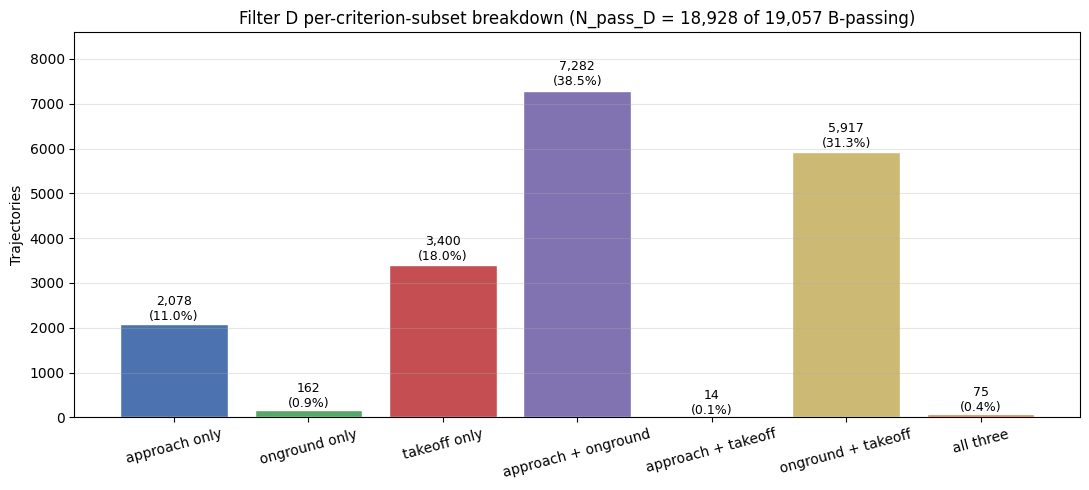


Reading guide:
  - Each bar shows trajectories caught EXCLUSIVELY by that criterion combination.
  - Large 'all three' bar = many trajectories are clearly LEMD operations (arrived,
    were on ground, and were in approach/takeoff regime).
  - Non-trivial 'approach only' bar = holds / missed approaches / GAs the other
    criteria miss but criterion 1 catches.
  - Non-trivial 'takeoff only' bar = LEMD departures with delayed ADS-B (the 97.9%
    finding from Phase 0c).
  - All three single-criterion bars non-trivial = criteria are complementary,
    not redundant. Each pulls real weight.


In [22]:
# Filter D calibration — pass rates + per-criterion contribution

n_total = len(per_traj)
n_pass_d = int(per_traj["pass_d"].sum())
n_pass_d_approach = int(per_traj["pass_d_approach"].sum())
n_pass_d_onground = int(per_traj["pass_d_onground"].sum())
n_pass_d_takeoff  = int(per_traj["pass_d_takeoff"].sum())

print("=" * 70)
print(f"Filter D calibration ({n_total:,} Filter-B-passing trajectories)")
print("=" * 70)
print()
print(f"  Filter B (ingestion gate, baseline):       {n_total:,} (100.0%)")
print(f"  Filter D (current LEMD-operation gate):    {n_pass_d:,} "
      f"({100*n_pass_d/n_total:.1f}%)")
print(f"  Filter C2 (historical, for comparison):    {int(per_traj['pass_c2'].sum()):,} "
      f"({100*per_traj['pass_c2'].mean():.1f}%)")
print()
print("Per-criterion pass counts (trajectories passing each criterion, not exclusive):")
print(f"  Criterion 1 (approach < 10km):                       {n_pass_d_approach:>6,} "
      f"({100*n_pass_d_approach/n_total:.1f}%)")
print(f"  Criterion 2 (onground < 5km):                        {n_pass_d_onground:>6,} "
      f"({100*n_pass_d_onground/n_total:.1f}%)")
print(f"  Criterion 3 (takeoff < 5km, alt < 2km):              {n_pass_d_takeoff:>6,} "
      f"({100*n_pass_d_takeoff/n_total:.1f}%)")
print()

# Per-subset breakdown (which trajectories satisfy which combination)
import itertools
labels = {("A",): "approach only",
          ("O",): "onground only",
          ("T",): "takeoff only",
          ("A", "O"): "approach + onground",
          ("A", "T"): "approach + takeoff",
          ("O", "T"): "onground + takeoff",
          ("A", "O", "T"): "all three"}

A = per_traj["pass_d_approach"]
O = per_traj["pass_d_onground"]
T = per_traj["pass_d_takeoff"]
NotA, NotO, NotT = ~A, ~O, ~T

subset_counts = {
    ("A",):           int((A & NotO & NotT).sum()),
    ("O",):           int((NotA & O & NotT).sum()),
    ("T",):           int((NotA & NotO & T).sum()),
    ("A", "O"):       int((A & O & NotT).sum()),
    ("A", "T"):       int((A & NotO & T).sum()),
    ("O", "T"):       int((NotA & O & T).sum()),
    ("A", "O", "T"):  int((A & O & T).sum()),
}
n_pass_d_total = sum(subset_counts.values())  # sanity: should equal n_pass_d
n_fail = n_total - n_pass_d

print(f"Per-criterion-subset breakdown (each trajectory counted once):")
for subset, cnt in subset_counts.items():
    pct = 100 * cnt / n_total
    pct_of_d = 100 * cnt / n_pass_d if n_pass_d > 0 else 0
    print(f"  {labels[subset]:30s}  {cnt:>6,}  ({pct:5.1f}% of all, {pct_of_d:5.1f}% of D)")
print(f"  {'rejected by D (fail all)':30s}  {n_fail:>6,}  ({100*n_fail/n_total:5.1f}% of all)")
print()
print(f"  Sanity: subset sum = {n_pass_d_total:,}, pass_d = {n_pass_d:,} "
      f"(should match)")

# Plot
fig, ax = plt.subplots(figsize=(11, 5))
order = [("A",), ("O",), ("T",), ("A", "O"), ("A", "T"), ("O", "T"), ("A", "O", "T")]
bar_labels = [labels[s] for s in order]
bar_values = [subset_counts[s] for s in order]
colors = ["#4c72b0", "#55a868", "#c44e52", "#8172b2", "#937860", "#ccb974", "#dd8452"]
bars = ax.bar(bar_labels, bar_values, color=colors, edgecolor="white")
for bar, v in zip(bars, bar_values):
    h = bar.get_height()
    pct = 100 * v / n_pass_d if n_pass_d > 0 else 0
    ax.text(bar.get_x() + bar.get_width()/2, h*1.01, f"{v:,}\n({pct:.1f}%)",
            ha="center", va="bottom", fontsize=9)
ax.set_ylabel("Trajectories")
ax.set_title(f"Filter D per-criterion-subset breakdown (N_pass_D = {n_pass_d:,} "
             f"of {n_total:,} B-passing)")
ax.set_ylim(0, max(bar_values)*1.18)
ax.tick_params(axis="x", rotation=15)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / "03-filter-d-calibration.png", dpi=150, bbox_inches="tight")
plt.show()

print()
print("Reading guide:")
print("  - Each bar shows trajectories caught EXCLUSIVELY by that criterion combination.")
print("  - Large 'all three' bar = many trajectories are clearly LEMD operations (arrived,")
print("    were on ground, and were in approach/takeoff regime).")
print("  - Non-trivial 'approach only' bar = holds / missed approaches / GAs the other")
print("    criteria miss but criterion 1 catches.")
print("  - Non-trivial 'takeoff only' bar = LEMD departures with delayed ADS-B (the 97.9%")
print("    finding from Phase 0c).")
print("  - All three single-criterion bars non-trivial = criteria are complementary,")
print("    not redundant. Each pulls real weight.")

## Insight 4 — Arrival/departure endpoint structure

**Question:** of the trajectories that have ground-state contact, are they arrivals (end on ground), departures (start on ground), or round-trips (both)?

**Finding:**
- 31% start on_ground only → departures from LEMD (~5,937).
- 25% end on_ground only → arrivals at LEMD (~4,732).
- 0.8% both start AND end on_ground → round-trips (~159).
- 43% neither → trajectories that never touched ground but passed Filter B (cruise overflights, holding, transit; will be dropped by Filter C).

**Implication:** the 30-min segmentation gap is doing exactly what it should — each `flight_id` is *one direction of one flight*, almost never a round-trip. Aircraft turnaround times at LEMD exceed 30 minutes for nearly all commercial operations, so morning arrival and afternoon departure of the same aircraft become two separate trajectories. Validates the segmentation rule.

**Implication for Phase 6 (preview):** the LSTM AE will be trained on a mix of arrivals (~30%) and departures (~30%). The model needs to learn both distributions. Possible Phase 5 feature: a binary `is_arrival` flag, derived in preprocessing from the endpoint structure. Deferred to Phase 5 design.

![Insight 4](../backend/docs/ml/figures/04-eda/04-arrival-departure-endpoints.png)

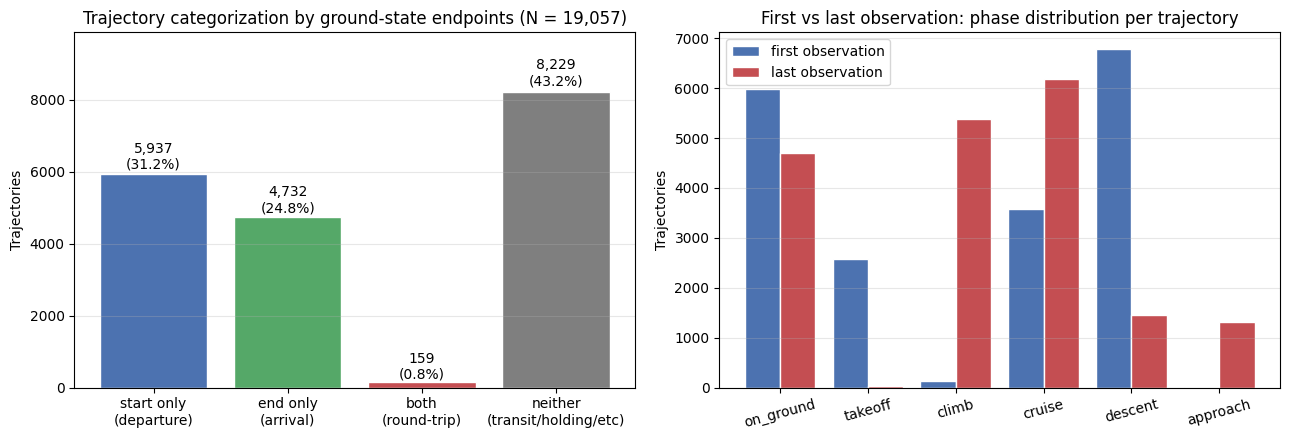

In [23]:
n_start_og = int(per_traj["start_any_onground"].sum())
n_end_og   = int(per_traj["end_any_onground"].sum())
n_both     = int((per_traj["start_any_onground"] & per_traj["end_any_onground"]).sum())
n_either   = int((per_traj["start_any_onground"] | per_traj["end_any_onground"]).sum())
n_neither  = len(per_traj) - n_either

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

cats = ["start only\n(departure)", "end only\n(arrival)", "both\n(round-trip)", "neither\n(transit/holding/etc)"]
vals = [n_start_og - n_both, n_end_og - n_both, n_both, n_neither]
colors_4 = ["#4c72b0", "#55a868", "#c44e52", "#7f7f7f"]
bars = ax1.bar(cats, vals, color=colors_4, edgecolor="white")
for bar, v in zip(bars, vals):
    h = bar.get_height(); pct = 100*v/len(per_traj)
    ax1.text(bar.get_x()+bar.get_width()/2, h*1.01, f"{v:,}\n({pct:.1f}%)",
             ha="center", va="bottom", fontsize=10)
ax1.set_ylabel("Trajectories")
ax1.set_title(f"Trajectory categorization by ground-state endpoints (N = {len(per_traj):,})")
ax1.set_ylim(0, max(vals)*1.20); ax1.grid(axis="y", alpha=0.3)

phase_order = ["on_ground", "takeoff", "climb", "cruise", "descent", "approach"]
fp_counts = per_traj["first_phase"].value_counts().reindex(phase_order, fill_value=0)
lp_counts = per_traj["last_phase"].value_counts().reindex(phase_order, fill_value=0)
x = np.arange(len(phase_order)); w = 0.4
ax2.bar(x - w/2, fp_counts.values, w, label="first observation", color="#4c72b0", edgecolor="white")
ax2.bar(x + w/2, lp_counts.values, w, label="last observation",  color="#c44e52", edgecolor="white")
ax2.set_xticks(x); ax2.set_xticklabels(phase_order, rotation=15)
ax2.set_ylabel("Trajectories")
ax2.set_title("First vs last observation: phase distribution per trajectory")
ax2.legend(); ax2.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / "04-arrival-departure-endpoints.png", dpi=150, bbox_inches="tight")
plt.show()

## Insight 5 — Map: trajectories kept vs rejected by Filter D

**Question:** does Filter D visually keep LEMD operations (arrivals, departures, holds, missed approaches) and drop overflights / transit / distant traffic?

**Method:** randomly sample 30 trajectories that pass Filter D and 30 that fail. Plot each in lon/lat space, with LEMD marked. Both subplots use the same axis range so the comparison is fair.

**Finding (visual sanity, from saved figure):** kept trajectories should cluster around LEMD with the classic mix of approach/departure cones, holding patterns, and missed-approach loops — the full operational variety. Rejected trajectories should be visibly farther out, dominated by through-traffic at altitudes that never came close to LEMD.

**Critical comparison with old C2 result:** under C2, the rejected set contained class 2 (holds), class 3 (missed approaches), and class 4 (ADS-B-clipped real landings) that we now want to keep. The Filter D rejected set should NOT include those — it should look much "cleaner" (more uniformly transit/overflight).

![Insight 5](../backend/docs/ml/figures/04-eda/05-trajectory-map-d-kept-vs-rejected.png)

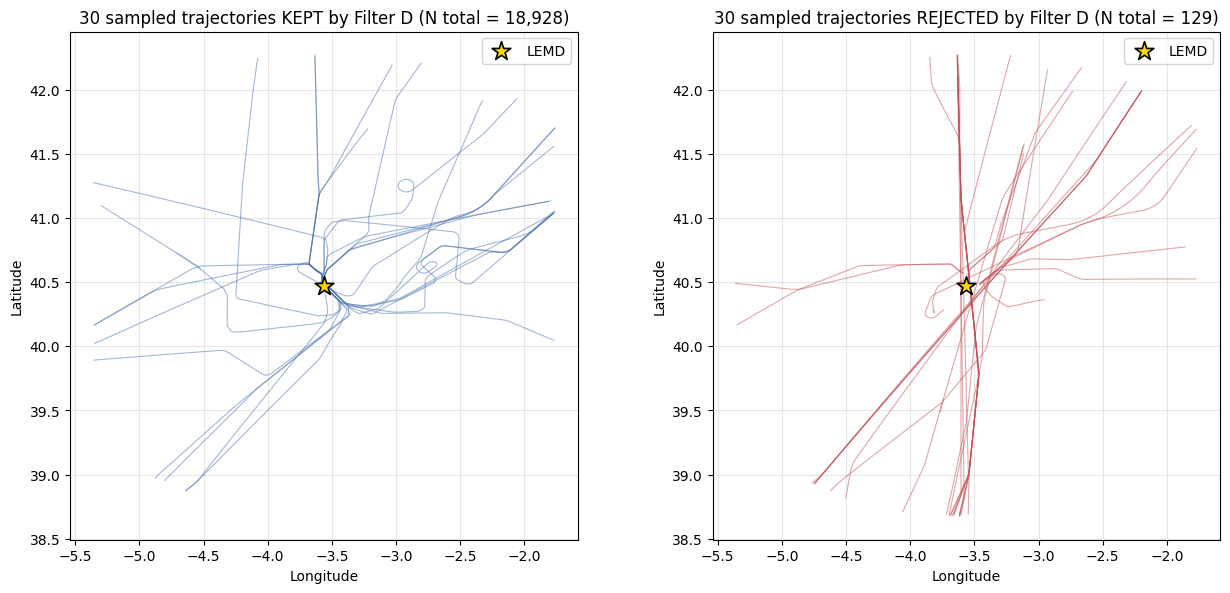


What to look at (eye check the figure):
  Kept (left):    approach cones into LEMD, holding patterns nearby,
                  short trajectories near runway (delayed-ADS-B departures).
                  All visibly engaged with LEMD's operational system.
  Rejected (right): trajectories visibly distant from LEMD with no near-pass
                    or with brief peripheral contact at altitude. Should NOT
                    contain trajectories whose middle visibly passes through LEMD
                    (those would indicate Filter D is still too strict).


In [24]:
# Filter D map — 30 kept + 30 rejected
LEMD_LAT, LEMD_LON = 40.4719, -3.5626
rng = np.random.default_rng(42)

ids_kept = rng.choice(per_traj.loc[per_traj["pass_d"], "flight_id"].values, size=30, replace=False)
ids_drop = rng.choice(per_traj.loc[~per_traj["pass_d"], "flight_id"].values, size=30, replace=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
for ax, ids, color, title in [
    (axes[0], ids_kept, "#4c72b0", f"30 sampled trajectories KEPT by Filter D (N total = {int(per_traj['pass_d'].sum()):,})"),
    (axes[1], ids_drop, "#c44e52", f"30 sampled trajectories REJECTED by Filter D (N total = {int((~per_traj['pass_d']).sum()):,})"),
]:
    for fid in ids:
        sub = df.loc[df["flight_id"] == fid].sort_values("time")
        ax.plot(sub["lon"], sub["lat"], color=color, alpha=0.5, linewidth=0.8)
    ax.scatter([LEMD_LON], [LEMD_LAT], marker="*", s=200, color="gold",
               edgecolor="black", linewidth=1.2, label="LEMD", zorder=5)
    ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
    ax.set_title(title); ax.set_aspect("equal", adjustable="box")
    ax.legend(loc="upper right"); ax.grid(alpha=0.3)

all_ids = np.concatenate([ids_kept, ids_drop])
sub_all = df.loc[df["flight_id"].isin(all_ids)]
lon_pad = (sub_all["lon"].max()-sub_all["lon"].min())*0.05
lat_pad = (sub_all["lat"].max()-sub_all["lat"].min())*0.05
for ax in axes:
    ax.set_xlim(sub_all["lon"].min()-lon_pad, sub_all["lon"].max()+lon_pad)
    ax.set_ylim(sub_all["lat"].min()-lat_pad, sub_all["lat"].max()+lat_pad)

plt.tight_layout()
plt.savefig(FIG_DIR / "05-trajectory-map-d-kept-vs-rejected.png", dpi=150, bbox_inches="tight")
plt.show()

print()
print("What to look at (eye check the figure):")
print("  Kept (left):    approach cones into LEMD, holding patterns nearby,")
print("                  short trajectories near runway (delayed-ADS-B departures).")
print("                  All visibly engaged with LEMD's operational system.")
print("  Rejected (right): trajectories visibly distant from LEMD with no near-pass")
print("                    or with brief peripheral contact at altitude. Should NOT")
print("                    contain trajectories whose middle visibly passes through LEMD")
print("                    (those would indicate Filter D is still too strict).")

## Insight 6 — Operational engagement signature: (min trajectory altitude, min distance to LEMD)

**Question:** in the (whole-trajectory minimum altitude, whole-trajectory minimum distance to LEMD) plane, do Filter D's pass/fail decisions align with a natural break in the data?

**Method:** 2D scatter of `(per_traj["min_dist"]/1000, per_traj["min_alt"])` for all 19,057 trajectories, colored by D pass/fail. Log-x scale because distance distribution spans 0.01 → 200 km. Reference markers for LEMD field elevation (~609 m AMSL) and the criterion thresholds.

**Why this is the right visualization for Filter D (not the old C2 endpoint heatmap):** Filter D's criteria are about *any observation* in the trajectory, not endpoint observations. The right summary stats are therefore **whole-trajectory minimums** (closest the aircraft ever got to LEMD, lowest altitude it ever reached). Trajectories truly engaged with LEMD will have low values on both axes; trajectories that never engaged will have high values.

**Expected finding:** D-passing trajectories cluster in the low-low corner (close to LEMD, low altitude reached) — that's the operationally-engaged regime. D-rejected trajectories should fall in the high-distance and/or high-altitude regions — the transit/overflight regime. A clean visual separation between the two regions defends Filter D's calibration.

![Insight 6](../backend/docs/ml/figures/04-eda/06-engagement-signature-d.png)

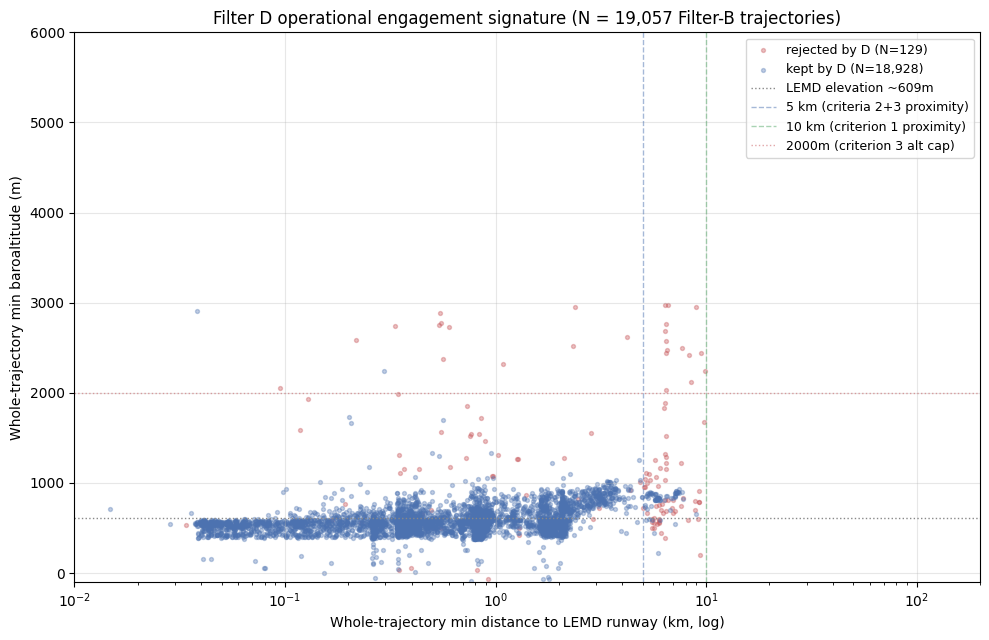


What to look at:
  - D-passing (blue) trajectories cluster in the low-low corner — close to LEMD,
    low altitude. This is the operationally-engaged regime.
  - D-rejected (red) trajectories should populate the high-distance OR
    high-altitude regions — transit / overflight / distant traffic that never
    operationally engaged with LEMD.
  - A clean visual separation between blue cluster and red region defends the
    Filter D calibration. Mixing (red dots scattered within the blue cluster, or
    vice versa) would indicate the thresholds need tightening or loosening.


In [25]:
# Filter D operational engagement signature
end_min_dist_km = per_traj["min_dist"] / 1000
end_min_alt = per_traj["min_alt"]

# Plot D-passing vs D-rejected in (min_dist, min_alt) space
fig, ax = plt.subplots(figsize=(10, 6.5))
mask_kept = per_traj["pass_d"]
mask_drop = ~mask_kept

sample_kept = per_traj.loc[mask_kept].sample(min(5000, int(mask_kept.sum())), random_state=42)
sample_drop = per_traj.loc[mask_drop].sample(min(5000, int(mask_drop.sum())), random_state=42)

ax.scatter(sample_drop["min_dist"]/1000, sample_drop["min_alt"],
           s=8, alpha=0.35, color="#c44e52", label=f"rejected by D (N={int(mask_drop.sum()):,})")
ax.scatter(sample_kept["min_dist"]/1000, sample_kept["min_alt"],
           s=8, alpha=0.35, color="#4c72b0", label=f"kept by D (N={int(mask_kept.sum()):,})")

# Reference markers
ax.axhline(609, color="#888", linestyle=":", linewidth=1, label="LEMD elevation ~609m")
ax.axvline(5, color="#4c72b0", linestyle="--", linewidth=1, alpha=0.5,
           label="5 km (criteria 2+3 proximity)")
ax.axvline(10, color="#55a868", linestyle="--", linewidth=1, alpha=0.5,
           label="10 km (criterion 1 proximity)")
ax.axhline(2000, color="#c44e52", linestyle=":", linewidth=1, alpha=0.5,
           label="2000m (criterion 3 alt cap)")

ax.set_xscale("log")
ax.set_xlim(0.01, 200)
ax.set_ylim(-100, 6000)
ax.set_xlabel("Whole-trajectory min distance to LEMD runway (km, log)")
ax.set_ylabel("Whole-trajectory min baroaltitude (m)")
ax.set_title(f"Filter D operational engagement signature "
             f"(N = {len(per_traj):,} Filter-B trajectories)")
ax.legend(loc="upper right", fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / "06-engagement-signature-d.png", dpi=150, bbox_inches="tight")
plt.show()

print()
print("What to look at:")
print("  - D-passing (blue) trajectories cluster in the low-low corner — close to LEMD,")
print("    low altitude. This is the operationally-engaged regime.")
print("  - D-rejected (red) trajectories should populate the high-distance OR")
print("    high-altitude regions — transit / overflight / distant traffic that never")
print("    operationally engaged with LEMD.")
print("  - A clean visual separation between blue cluster and red region defends the")
print("    Filter D calibration. Mixing (red dots scattered within the blue cluster, or")
print("    vice versa) would indicate the thresholds need tightening or loosening.")

## Insight 7 — Motion-feature normality audit

**Question:** Filter D selected trajectories that operationally engaged with LEMD. But are the within-trajectory motion patterns plausible for cooperating manned aviation? Are there gross outliers — sensor glitches, impossible kinematics, or anomalies that snuck through Filter D — sitting in the would-be training corpus?

**Method:** for the 18,928 D-passing trajectories' observations:

1. **Distribution check (7a)** — histograms of `velocity`, `vertrate`, `baroaltitude`, and per-row heading-change rate. Reference markers at known physical/operational bounds. Tail counts identified.
2. **Cross-feature impossibility check (7b)** — 2D scatter of (velocity, altitude). Impossible combinations (e.g., sub-stall at altitude, supersonic at low altitude) flagged.
3. **Top-K outlier inspection (7c)** — for each motion feature, identify the 20 trajectories with the most extreme values and plot them on a map. Visual eyeball: real anomalies, sensor glitches, or normal-tail aircraft?

**Goal:** quantify gross-outlier prevalence in the would-be training corpus. Document the limitation if non-trivial; propose a Phase 3 outlier-removal rule if needed.

**Important caveat:** EDA can only catch **gross sensor anomalies and impossible kinematics**. Subtle behavioral anomalies (pilot deviation, mode confusion, hijack) require Phase 7's D-008 Layer 4 external validation against real 7700-squawk emergencies (Olive et al., 2020). That's what answers "does the model catch behaviorally-unusual but kinematically-plausible flights?" — orthogonal to what Insight 7 covers.

Auditing 3,409,222 observations across 18,928 D-passing trajectories.

Outlier tail counts (D-passing observations):
  velocity            >    320      m/s (suspicious):     138  ( 0.00%)
  velocity            >    400      m/s (impossible):      69  ( 0.00%)
  vertrate            >     25      m/s (suspicious):   1,382  ( 0.04%)
  vertrate            >     50      m/s (impossible):     164  ( 0.00%)
  baroaltitude        >  14000        m (suspicious):   3,408  ( 0.10%)
  baroaltitude        >  16000        m (impossible):   2,751  ( 0.08%)
  heading_change      >     15  deg/10s (suspicious):  94,945  ( 2.78%)
  heading_change      >     30  deg/10s (impossible):   5,448  ( 0.16%)



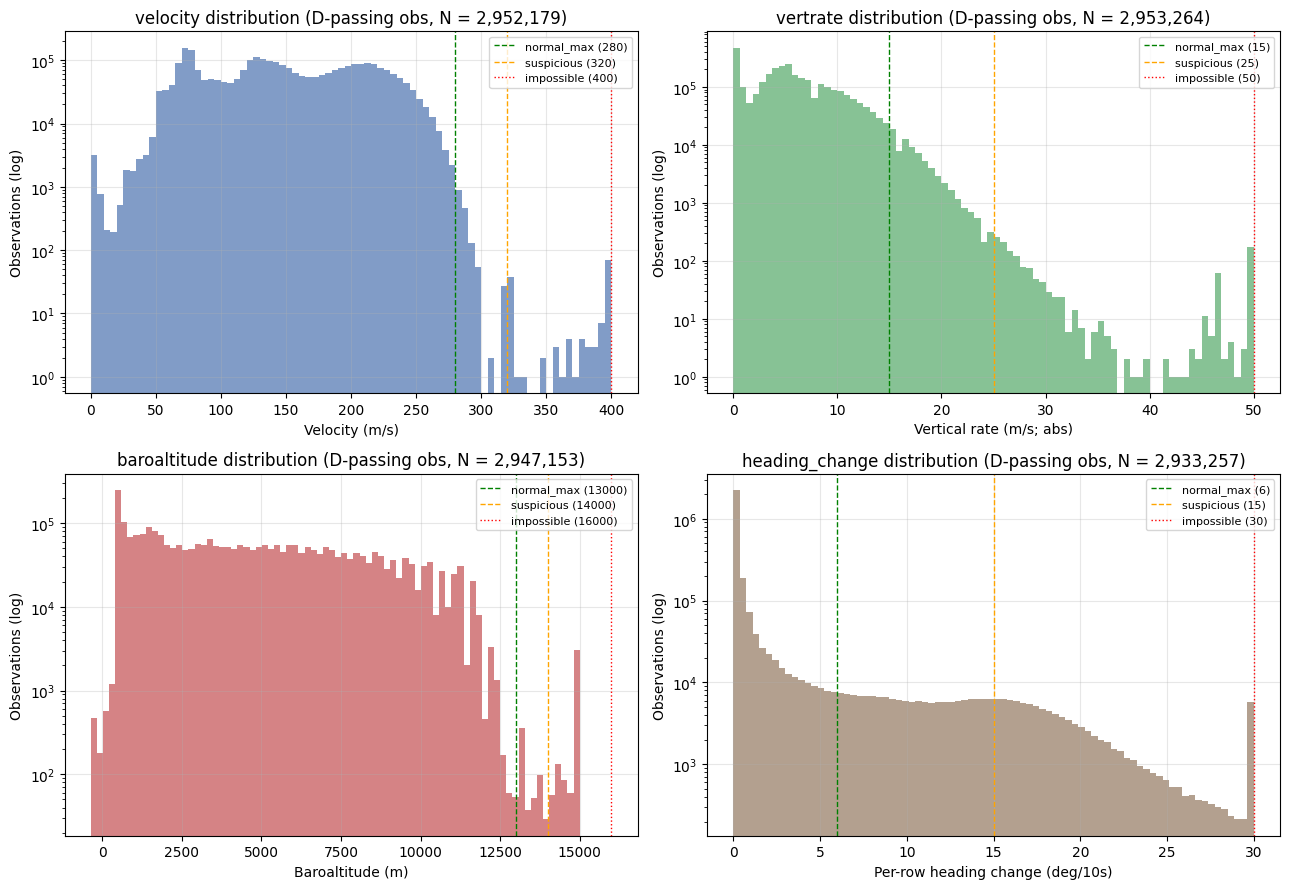

Reading guide:
  - Vertical lines mark reference bounds for cooperating civil aviation:
    GREEN = normal_max (typical upper for routine ops)
    ORANGE = suspicious (uncommon but possible — aggressive maneuvering or extreme aircraft)
    RED = impossible (outside the physical envelope of nearly all civil aircraft)
  - Observations beyond the red line are likely sensor glitches or pre-training anomalies.
  - Observations between orange and red are tail outliers — worth inspecting in 7c.


In [26]:
# Insight 7a — Motion feature distribution histograms

# Subset to D-passing trajectories' observations
d_flight_ids = per_traj.loc[per_traj["pass_d"], "flight_id"].values
df_d = df[df["flight_id"].isin(d_flight_ids)].copy()
df_d = df_d.sort_values(["flight_id", "time"]).reset_index(drop=True)

# Compute per-row heading change (handle 360° wrap-around)
df_d["heading_change"] = df_d.groupby("flight_id")["heading"].diff().abs()
df_d.loc[df_d["heading_change"] > 180, "heading_change"] = (
    360 - df_d.loc[df_d["heading_change"] > 180, "heading_change"]
)

n_obs = len(df_d)
print(f"Auditing {n_obs:,} observations across {len(d_flight_ids):,} D-passing trajectories.")
print()

# Reference bounds (cooperating civil aviation)
ref = {
    "velocity":         {"normal_max": 280, "suspicious": 320, "impossible": 400, "unit": "m/s"},
    "vertrate":         {"normal_max": 15,  "suspicious": 25,  "impossible": 50,  "unit": "m/s"},
    "baroaltitude":     {"normal_max": 13000, "suspicious": 14000, "impossible": 16000, "unit": "m"},
    "heading_change":   {"normal_max": 6,   "suspicious": 15,  "impossible": 30,  "unit": "deg/10s"},
}

# Tail counts
print(f"Outlier tail counts (D-passing observations):")
for col, r in ref.items():
    series = df_d[col].abs().dropna() if col == "vertrate" else df_d[col].dropna()
    n_sus  = int((series > r["suspicious"]).sum())
    n_imp  = int((series > r["impossible"]).sum())
    print(f"  {col:18s}  > {r['suspicious']:>6} {r['unit']:>8s} (suspicious): {n_sus:>7,}  ({100*n_sus/n_obs:5.2f}%)")
    print(f"  {col:18s}  > {r['impossible']:>6} {r['unit']:>8s} (impossible): {n_imp:>7,}  ({100*n_imp/n_obs:5.2f}%)")
print()

# 4-panel histogram
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

panels = [
    ("velocity",       axes[0,0], "#4c72b0", "Velocity (m/s)", 400),
    ("vertrate",       axes[0,1], "#55a868", "Vertical rate (m/s; abs)", 50),
    ("baroaltitude",   axes[1,0], "#c44e52", "Baroaltitude (m)", 15000),
    ("heading_change", axes[1,1], "#937860", "Per-row heading change (deg/10s)", 30),
]

for col, ax, color, label, x_max in panels:
    series = df_d[col].abs() if col == "vertrate" else df_d[col]
    series = series.dropna().clip(upper=x_max)
    ax.hist(series, bins=80, color=color, alpha=0.7, log=True)
    r = ref[col]
    ax.axvline(r["normal_max"],   color="green",  linestyle="--", linewidth=1,
               label=f"normal_max ({r['normal_max']})")
    ax.axvline(r["suspicious"],   color="orange", linestyle="--", linewidth=1,
               label=f"suspicious ({r['suspicious']})")
    ax.axvline(r["impossible"],   color="red",    linestyle=":",  linewidth=1,
               label=f"impossible ({r['impossible']})")
    ax.set_xlabel(label)
    ax.set_ylabel("Observations (log)")
    ax.set_title(f"{col} distribution (D-passing obs, N = {int(series.notna().sum()):,})")
    ax.legend(loc="upper right", fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / "07a-motion-feature-distributions.png", dpi=150, bbox_inches="tight")
plt.show()

print("Reading guide:")
print("  - Vertical lines mark reference bounds for cooperating civil aviation:")
print("    GREEN = normal_max (typical upper for routine ops)")
print("    ORANGE = suspicious (uncommon but possible — aggressive maneuvering or extreme aircraft)")
print("    RED = impossible (outside the physical envelope of nearly all civil aircraft)")
print("  - Observations beyond the red line are likely sensor glitches or pre-training anomalies.")
print("  - Observations between orange and red are tail outliers — worth inspecting in 7c.")

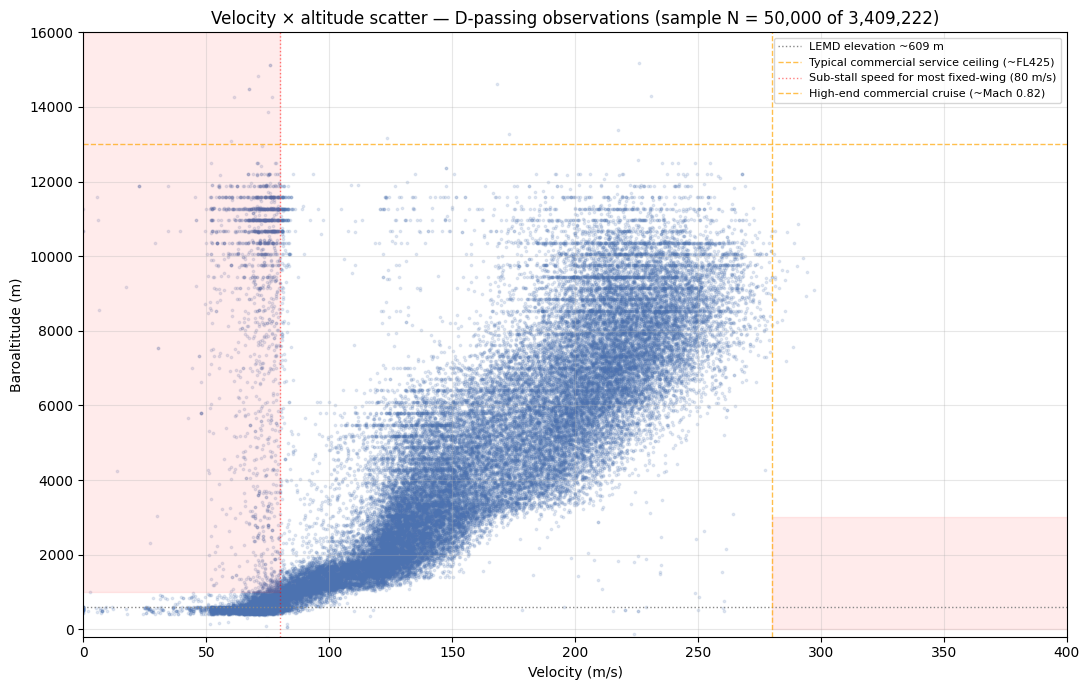

Observations in 'suspicious' regions:
  Slow at altitude (velocity < 80 m/s AND alt > 1000 m): 95,761 (2.81%)
  Fast at low altitude (velocity > 280 m/s AND alt < 3000 m): 21 (0.00%)

Reading guide:
  - The bulk of points should fall in the 'L' shape:
    LOW SPEED (< 100 m/s) at LOW ALTITUDE (< 1500 m) — approach / departure / on_ground
    HIGH SPEED (150-280 m/s) at HIGH ALTITUDE (5000-13000 m) — cruise / climb / descent
  - The red-shaded regions are physically suspicious — anomalies or sensor glitches.
  - Points scattered across both red regions = sensor noise; clustered = anomalies.


In [27]:
# Insight 7b — Cross-feature impossibility check: (velocity, altitude) scatter

# Subsample for plot density (50k obs is enough to see structure without lag)
sample = df_d.dropna(subset=["velocity", "baroaltitude"]).sample(
    min(50000, len(df_d)), random_state=42)

fig, ax = plt.subplots(figsize=(11, 7))
ax.scatter(sample["velocity"], sample["baroaltitude"], s=3, alpha=0.15, color="#4c72b0")

# Reference: rough operational envelope for commercial aviation
# - Min speed at altitude (~stall * 1.3): increases with altitude
# - Max speed at altitude: ~Mach 0.85 at cruise
# - Service ceiling: ~13000 m

# Reference markers
ax.axhline(609, color="#888", linestyle=":", linewidth=1, label="LEMD elevation ~609 m")
ax.axhline(13000, color="orange", linestyle="--", linewidth=1, alpha=0.7,
           label="Typical commercial service ceiling (~FL425)")
ax.axvline(80, color="red", linestyle=":", linewidth=1, alpha=0.5,
           label="Sub-stall speed for most fixed-wing (80 m/s)")
ax.axvline(280, color="orange", linestyle="--", linewidth=1, alpha=0.7,
           label="High-end commercial cruise (~Mach 0.82)")

# Highlight "impossible" regions
# Below 80 m/s above 1000 m altitude is suspicious for fixed-wing
import matplotlib.patches as mpatches
ax.fill_betweenx([1000, 16000], 0, 80, alpha=0.08, color="red", label=None)
# Above 280 m/s below 3000 m is unusual (high speed at low altitude)
ax.fill_betweenx([0, 3000], 280, 500, alpha=0.08, color="red", label=None)

ax.set_xlim(0, 400)
ax.set_ylim(-200, 16000)
ax.set_xlabel("Velocity (m/s)")
ax.set_ylabel("Baroaltitude (m)")
ax.set_title(f"Velocity × altitude scatter — D-passing observations "
             f"(sample N = {len(sample):,} of {len(df_d):,})")
ax.legend(loc="upper right", fontsize=8)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / "07b-velocity-altitude-scatter.png", dpi=150, bbox_inches="tight")
plt.show()

# Count points in suspicious regions
mask_slow_high = (df_d["velocity"] < 80) & (df_d["baroaltitude"] > 1000)
mask_fast_low  = (df_d["velocity"] > 280) & (df_d["baroaltitude"] < 3000)
n_slow_high = int(mask_slow_high.sum())
n_fast_low  = int(mask_fast_low.sum())

print(f"Observations in 'suspicious' regions:")
print(f"  Slow at altitude (velocity < 80 m/s AND alt > 1000 m): "
      f"{n_slow_high:,} ({100*n_slow_high/len(df_d):.2f}%)")
print(f"  Fast at low altitude (velocity > 280 m/s AND alt < 3000 m): "
      f"{n_fast_low:,} ({100*n_fast_low/len(df_d):.2f}%)")
print()
print("Reading guide:")
print("  - The bulk of points should fall in the 'L' shape:")
print("    LOW SPEED (< 100 m/s) at LOW ALTITUDE (< 1500 m) — approach / departure / on_ground")
print("    HIGH SPEED (150-280 m/s) at HIGH ALTITUDE (5000-13000 m) — cruise / climb / descent")
print("  - The red-shaded regions are physically suspicious — anomalies or sensor glitches.")
print("  - Points scattered across both red regions = sensor noise; clustered = anomalies.")

Per-trajectory extreme value statistics:
       max_velocity  max_vertrate  max_alt  max_heading_change
count       18789.0       18789.0  18928.0             18789.0
mean          225.2          16.2  10121.6                26.3
std            33.6           6.2   3449.0                19.9
min             0.0           0.0   -243.8                 0.0
50%           227.7          15.9  10058.4                21.6
90%           258.4          21.8  11590.0                37.1
99%           280.0          29.6  29740.3               129.5
max          1709.4         165.8  38648.6               180.0



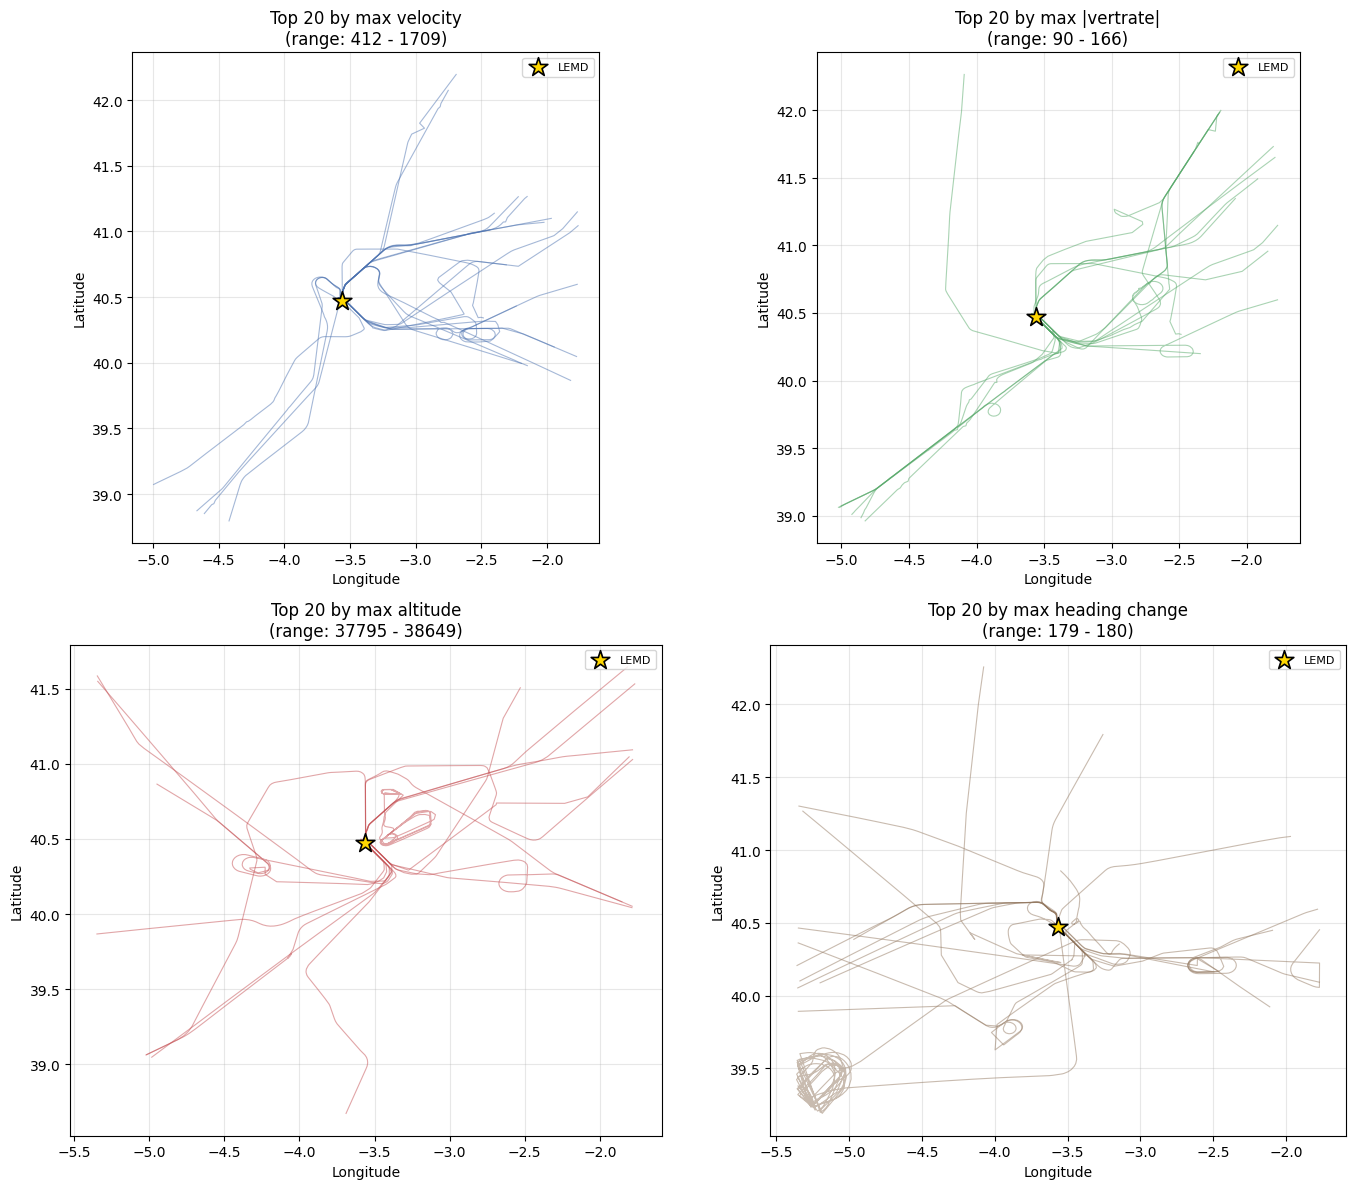


Top 20 trajectories by each metric (IDs for manual inspection):

Top 20 by max velocity:
        flight_id  max_velocity
738054_1517215050   1709.437266
3c6746_1517259810    820.910785
34615a_1580150110    743.539423
4ca666_1582534500    574.719606
4a08eb_1543835750    510.411935
344292_1543857530    504.548936
49d3fa_1543848580    480.099747
4b17fd_1543823400    477.947271
3423c3_1543818550    475.052754
345051_1543853670    460.321605
3451d8_1543832960    458.649835
3420cc_1543823410    441.246029
4ca88e_1543841090    437.761315
4ca4f3_1543828440    436.414098
4b1803_1543858650    433.292883
4bb855_1543834500    427.121759
342105_1543818500    425.185087
3453c1_1543865180    418.039170
342106_1543849380    417.001211
345052_1543849950    411.546197

Top 20 by max |vertrate|:
        flight_id  max_vertrate
34615a_1580150110     165.81120
4ca294_1532934370     140.45184
3c6746_1517259810     139.47648
738054_1517215050     135.57504
342105_1543865710     100.46208
020027_1543831270  

In [28]:
# Insight 7c — Top-K outlier trajectory maps

# Compute per-trajectory extreme statistics
df_d_for_extreme = df_d.copy()
df_d_for_extreme["vertrate_abs"] = df_d_for_extreme["vertrate"].abs()

extreme = (df_d_for_extreme.groupby("flight_id")
                .agg(max_velocity=("velocity", "max"),
                     max_vertrate=("vertrate_abs", "max"),
                     max_alt=("baroaltitude", "max"),
                     max_heading_change=("heading_change", "max"))
                .reset_index())

print("Per-trajectory extreme value statistics:")
print(extreme[["max_velocity", "max_vertrate", "max_alt", "max_heading_change"]].describe(
    percentiles=[0.50, 0.90, 0.99]
).round(1).to_string())
print()

# Top-K per metric — plot on maps
LEMD_LAT, LEMD_LON = 40.4719, -3.5626
K = 20

metrics = [
    ("max_velocity",       "Top 20 by max velocity",         "#4c72b0"),
    ("max_vertrate",       "Top 20 by max |vertrate|",       "#55a868"),
    ("max_alt",            "Top 20 by max altitude",         "#c44e52"),
    ("max_heading_change", "Top 20 by max heading change",   "#937860"),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for ax, (col, title, color) in zip(axes, metrics):
    top_ids = extreme.nlargest(K, col)["flight_id"].values
    top_vals = extreme.nlargest(K, col)[col].values

    for fid in top_ids:
        sub = df_d[df_d["flight_id"] == fid].sort_values("time")
        ax.plot(sub["lon"], sub["lat"], color=color, alpha=0.5, linewidth=0.8)

    ax.scatter([LEMD_LON], [LEMD_LAT], marker="*", s=200, color="gold",
               edgecolor="black", linewidth=1.2, label="LEMD", zorder=5)
    ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
    range_label = f"range: {top_vals.min():.0f} - {top_vals.max():.0f}"
    ax.set_title(f"{title}\n({range_label})")
    ax.set_aspect("equal", adjustable="box")
    ax.legend(loc="upper right", fontsize=8); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / "07c-top-k-outlier-maps.png", dpi=150, bbox_inches="tight")
plt.show()

# Print the IDs for manual inspection
print()
print(f"Top {K} trajectories by each metric (IDs for manual inspection):")
for col, title, _ in metrics:
    top_ids_vals = extreme.nlargest(K, col)[["flight_id", col]]
    print(f"\n{title}:")
    print(top_ids_vals.head(K).to_string(index=False))

### Insight 7d — Heading-change ground vs air split

**Hypothesis:** the 94,945 (2.78%) suspicious heading-change observations are dominated by **on-ground taxi turns**, not in-flight maneuvers. If confirmed, the "contamination" is structural (different feature semantics for ground vs air) and Phase 3 handles it via ground-state feature handling, not by filtering trajectories.

**Test:** split the suspicious heading-change observations by `onground` flag. Subset to air-only; inspect those geographically + by altitude / velocity / phase. If air-only are rare and concentrated near LEMD, they're real approach/departure turns; if scattered, possible sensor noise.

Suspicious heading-change observations (heading_change > 15 deg/10s): 94,945
  onground=True:      62  (0.1%)
  onground=False: 94,883  (99.9%)

Air-only suspicious heading-change (94,883 obs, 2.78% of all D-passing obs):
  Median altitude:        3048 m
  Median velocity:        133 m/s
  Median heading_change:  18 deg/10s

  Phase distribution:
flight_phase
descent     44753
takeoff     19096
cruise      15473
climb       12680
approach     2881



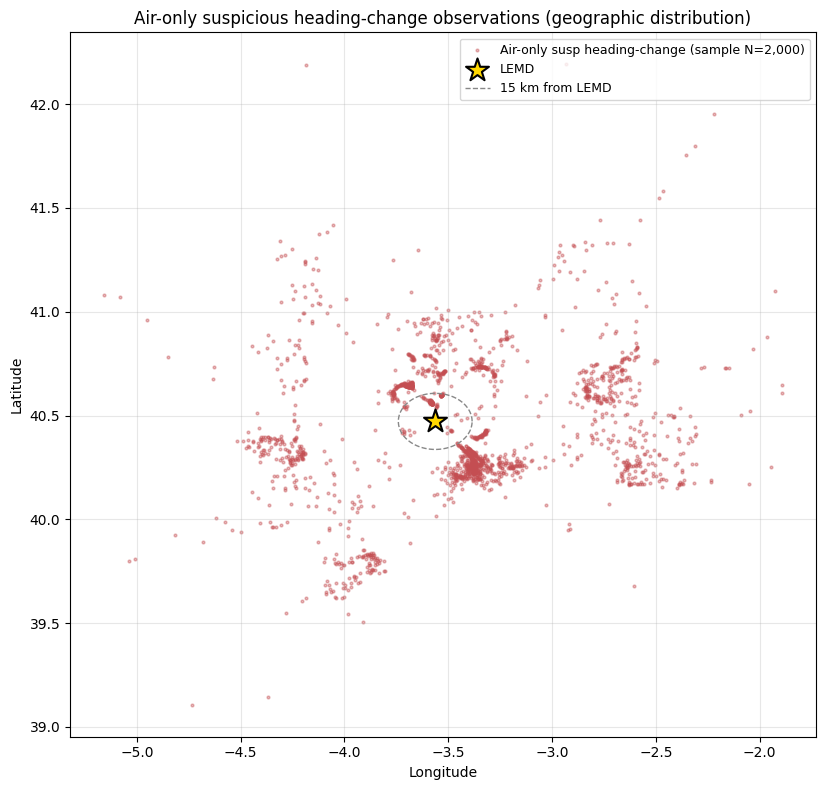

Reading guide:
  PASS (hypothesis confirmed) — ground rate > 80%, air-only obs cluster near LEMD
                                or correspond to known approach-turn geometries
                                (e.g., turn to final, base turn).
                                Phase 3 handles via ground-state feature handling.
  FAIL (hypothesis wrong)     — ground rate < 50%, or air-only obs scattered/distant
                                from LEMD with unusual altitude/velocity.
                                Phase 3 needs an explicit heading-change rule.


In [29]:
# Insight 7d — Heading change ground vs air split
mask_sus = df_d["heading_change"] > 15
df_sus = df_d[mask_sus].copy()
df_sus["onground_bool"] = df_sus["onground"].astype(bool)

n_total_sus = len(df_sus)
n_ground = int(df_sus["onground_bool"].sum())
n_air = n_total_sus - n_ground

print(f"Suspicious heading-change observations (heading_change > 15 deg/10s): "
      f"{n_total_sus:,}")
print(f"  onground=True:  {n_ground:>6,}  ({100*n_ground/n_total_sus:.1f}%)")
print(f"  onground=False: {n_air:>6,}  ({100*n_air/n_total_sus:.1f}%)")
print()

df_sus_air = df_sus[~df_sus["onground_bool"]]
print(f"Air-only suspicious heading-change ({len(df_sus_air):,} obs, "
      f"{100*len(df_sus_air)/len(df_d):.2f}% of all D-passing obs):")
print(f"  Median altitude:        {df_sus_air['baroaltitude'].median():.0f} m")
print(f"  Median velocity:        {df_sus_air['velocity'].median():.0f} m/s")
print(f"  Median heading_change:  {df_sus_air['heading_change'].median():.0f} deg/10s")
print()
print(f"  Phase distribution:")
print(df_sus_air['flight_phase'].value_counts().to_string())
print()

# Geographic distribution of air-only suspicious obs
fig, ax = plt.subplots(figsize=(10, 8))
sample = df_sus_air.sample(min(2000, len(df_sus_air)), random_state=42)
ax.scatter(sample["lon"], sample["lat"], s=4, alpha=0.4, c="#c44e52",
           label=f"Air-only susp heading-change (sample N={len(sample):,})")
ax.scatter([LEMD_LON], [LEMD_LAT], marker="*", s=300, c="gold",
           edgecolor="black", linewidth=1.5, label="LEMD", zorder=5)

theta = np.linspace(0, 2*np.pi, 100)
r_lat = 15 / 111.0
r_lon = 15 / (111.0 * np.cos(np.radians(LEMD_LAT)))
ax.plot(LEMD_LON + r_lon * np.cos(theta), LEMD_LAT + r_lat * np.sin(theta),
        color="#888", linestyle="--", linewidth=1, label="15 km from LEMD")

ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
ax.set_title("Air-only suspicious heading-change observations (geographic distribution)")
ax.set_aspect("equal", adjustable="box")
ax.legend(loc="upper right", fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / "07d-heading-change-air-vs-ground.png", dpi=150, bbox_inches="tight")
plt.show()

print("Reading guide:")
print("  PASS (hypothesis confirmed) — ground rate > 80%, air-only obs cluster near LEMD")
print("                                or correspond to known approach-turn geometries")
print("                                (e.g., turn to final, base turn).")
print("                                Phase 3 handles via ground-state feature handling.")
print("  FAIL (hypothesis wrong)     — ground rate < 50%, or air-only obs scattered/distant")
print("                                from LEMD with unusual altitude/velocity.")
print("                                Phase 3 needs an explicit heading-change rule.")

### Insight 7e — SW-corner heading-change cluster

**Observation from 7c top-K-by-heading-change map:** a tight cluster of trajectories with extreme heading changes around (lat 39.4, lon -5.1) — the SW corner of the bbox, well outside LEMD's TMA. What's there? Possibilities:
- A neighboring airport's holding pattern (e.g., LEBZ Badajoz, LERS Reus area)
- A military operating area with maneuvering traffic
- A specific aircraft type (helicopters, training aircraft)
- Sensor artifacts specific to that geographic region

**Test:** subset the SW-corner observations; look at their phase composition, altitude, velocity. Plot a few full trajectories to see if they form a recognizable operational pattern.

In [ ]:
# Insight 7e — SW-corner heading-change cluster investigation

# Geographic subset
sw_mask = (df_d["lat"] < 39.7) & (df_d["lon"] < -4.8)
sw_obs = df_d[sw_mask]
sw_traj_ids = sw_obs["flight_id"].unique()

print(f"Observations in SW corner (lat < 39.7, lon < -4.8): {len(sw_obs):,}")
print(f"  Across {len(sw_traj_ids)} unique trajectories")
print()

if len(sw_obs) == 0:
    print("  No observations in this region — the 7c top-K cluster may have been")
    print("  visual misperception of trajectories transiting through.")
else:
    print(f"Phase composition of SW-corner obs:")
    print(sw_obs["flight_phase"].value_counts().to_string())
    print()
    print(f"Altitude distribution: "
          f"median = {sw_obs['baroaltitude'].median():.0f} m, "
          f"P10 = {sw_obs['baroaltitude'].quantile(0.1):.0f} m, "
          f"P90 = {sw_obs['baroaltitude'].quantile(0.9):.0f} m")
    print(f"Velocity distribution: "
          f"median = {sw_obs['velocity'].median():.0f} m/s, "
          f"P10 = {sw_obs['velocity'].quantile(0.1):.0f} m/s, "
          f"P90 = {sw_obs['velocity'].quantile(0.9):.0f} m/s")
    print()

    # Sample of full trajectories from this region
    rng = np.random.default_rng(42)
    sample_n = min(10, len(sw_traj_ids))
    sample_ids = rng.choice(sw_traj_ids, size=sample_n, replace=False)

    fig, ax = plt.subplots(figsize=(11, 8))
    for fid in sample_ids:
        sub = df_d[df_d["flight_id"] == fid].sort_values("time")
        ax.plot(sub["lon"], sub["lat"], alpha=0.5, linewidth=0.8)
    ax.scatter([LEMD_LON], [LEMD_LAT], marker="*", s=300, c="gold",
               edgecolor="black", linewidth=1.5, label="LEMD", zorder=5)
    ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
    ax.set_title(f"SW-corner trajectories — {sample_n} random samples (of "
                 f"{len(sw_traj_ids)} total)")
    ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(FIG_DIR / "07e-sw-corner-investigation.png", dpi=150,
                bbox_inches="tight")
    plt.show()

    print()
    print("Reading guide:")
    print("  - Compact loops at the SW = local pattern flying (training, hold)")
    print("  - Long transits through the SW = traffic from outside the bbox")
    print("  - Mostly low altitude = local operations; mostly cruise altitude = transit")

### Insight 7f — Impossible-altitude trajectory inspection

**Goal:** confirm that the 2,751 obs with baroaltitude > 16,000 m are sensor-glitch spikes within otherwise normal trajectories (single-obs spikes), not systematically anomalous trajectories.

**Test:** for the affected trajectories, compute the share of impossible-altitude observations per trajectory. If most trajectories have just 1-2 spike observations out of hundreds, it's clearly sensor noise. If some trajectories have most observations above 16,000 m, those are systematic anomalies (different cause: maybe a transponder type that reports incorrect altitude).

**Plot:** for 5 affected trajectories, show (a) the full lat/lon path with impossible-altitude observations marked, and (b) the altitude-over-time profile showing where the spikes occur.

In [ ]:
# Insight 7f — Impossible-altitude trajectory inspection

mask_imp_alt = df_d["baroaltitude"] > 16000
df_imp = df_d[mask_imp_alt]
imp_traj_ids = df_imp["flight_id"].unique()

print(f"Observations with baroaltitude > 16,000 m: {len(df_imp):,}")
print(f"  Across {len(imp_traj_ids):,} unique trajectories")
print(f"  Avg impossible obs per affected trajectory: "
      f"{len(df_imp)/len(imp_traj_ids):.1f}")
print()

# Per-trajectory share of impossible-altitude obs
high_per_traj = df_imp.groupby("flight_id").size().reset_index(name="n_high")
total_per_traj = (df_d[df_d["flight_id"].isin(imp_traj_ids)]
                  .groupby("flight_id").size().reset_index(name="n_total"))
merged = high_per_traj.merge(total_per_traj, on="flight_id")
merged["share_high"] = merged["n_high"] / merged["n_total"]

print(f"Per-trajectory share of impossible-altitude observations:")
print(f"  P10 = {merged['share_high'].quantile(0.1)*100:.2f}%")
print(f"  P50 = {merged['share_high'].quantile(0.5)*100:.2f}%")
print(f"  P90 = {merged['share_high'].quantile(0.9)*100:.2f}%")
print(f"  Max = {merged['share_high'].max()*100:.2f}%")
print()

# Plot 5 affected trajectories
rng = np.random.default_rng(42)
sample_n = min(5, len(imp_traj_ids))
sample_ids = list(rng.choice(imp_traj_ids, size=sample_n, replace=False))

fig, axes = plt.subplots(sample_n, 2, figsize=(13, 3.5*sample_n))
if sample_n == 1:
    axes = axes.reshape(1, -1)

for i, fid in enumerate(sample_ids):
    sub = df_d[df_d["flight_id"] == fid].sort_values("time").reset_index(drop=True)

    # Left: lat/lon path
    axes[i, 0].plot(sub["lon"], sub["lat"], color="#4c72b0", alpha=0.7, linewidth=0.8)
    axes[i, 0].scatter([LEMD_LON], [LEMD_LAT], marker="*", s=200, c="gold",
                       edgecolor="black", zorder=5)
    bad = sub[sub["baroaltitude"] > 16000]
    axes[i, 0].scatter(bad["lon"], bad["lat"], s=20, c="red",
                       label=f"impossible alt obs (N={len(bad)})", zorder=4)
    axes[i, 0].set_title(f"{fid} — path")
    axes[i, 0].set_xlabel("Lon"); axes[i, 0].set_ylabel("Lat")
    axes[i, 0].legend(fontsize=8); axes[i, 0].grid(alpha=0.3)
    axes[i, 0].set_aspect("equal", adjustable="box")

    # Right: altitude over obs index
    axes[i, 1].plot(range(len(sub)), sub["baroaltitude"], color="#c44e52",
                    alpha=0.7, linewidth=0.8)
    axes[i, 1].axhline(16000, color="red", linestyle="--", linewidth=1,
                       label="16,000 m (impossible)")
    axes[i, 1].axhline(13000, color="green", linestyle=":", linewidth=1,
                       label="13,000 m (typical ceiling)")
    axes[i, 1].set_title(f"{fid} — altitude profile (N obs = {len(sub)})")
    axes[i, 1].set_xlabel("Observation index")
    axes[i, 1].set_ylabel("Baroaltitude (m)")
    axes[i, 1].legend(fontsize=8); axes[i, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / "07f-impossible-altitude-inspection.png", dpi=150,
            bbox_inches="tight")
plt.show()

print()
print("Reading guide:")
print("  - P50 share < 5% → most affected trajectories have a handful of spike obs,")
print("    rest is normal. Drop the bad observations, keep the trajectories.")
print("  - P50 share > 30% → entire trajectories are anomalous. Drop the trajectories")
print("    (a different transponder type, calibration issue, or systematic GPS error).")
print("  - Altitude-over-time plots: spikes return to normal in 1-2 obs = sensor noise;")
print("    sustained at impossible altitude = systematic issue.")

### Insight 7 — Multi-detector architecture and sanity-validation cohort (locked)

**The architectural principle.** Different anomaly classes deserve different detectors. The original two-layer framing assumed the AE catches everything; the post-Phase-1 reframe (`09-the-architectural-critique.md`) narrowed the AE's domain to behavioral anomalies on cooperating aircraft. Kinematic impossibilities (impossible velocity / vertrate / altitude) belong to a *different* anomaly class — they're cheaper, faster, and more reliably caught by a simple physical-bounds rule at preprocessing time.

**The multi-detector pipeline (locked for Phase 3 / D-010):**

```
raw ADS-B trajectory
     ↓
Stage 1: physical-bounds check
   - velocity > 400 m/s OR |vertrate| > 50 m/s OR baroaltitude > 16,000 m OR baroaltitude < -100 m
   - if violated: LOG "kinematic impossibility alert" per observation, per trajectory
   - this is the spoof / glitch detection channel
     ↓
Stage 2: imputation
   - linearly interpolate bad observations from valid neighbors
   - preserves trajectory length + uniform 10s time grid
   - same rule at training and at inference (Guardrail #9 — offline/online parity)
     ↓
Stage 3: LSTM AE
   - trained and evaluated on imputed (clean-by-construction) trajectories
   - outputs reconstruction-error anomaly score
     ↓
Combined operator dashboard
   - Stage 1 alerts (rule-based) AND Stage 3 score (model-based)
   - operator sees both signals; different anomaly classes covered
```

**What this gains over a "let the AE catch everything" design:**

- **Kinematic impossibility is caught even if the AE doesn't fire** (the AE might be wrong; the rule is deterministic).
- **The AE doesn't false-positive on glitched observations** (they're imputed away before reaching the model).
- **Inference-time parity holds** (same preprocessing at training and inference; no offline/online drift).
- **A sloppy-spoof signal is caught** (an attacker emitting impossible kinematics fires Stage 1). A sophisticated spoof with plausible kinematics is *out of scope* — it requires multi-sensor crosscheck, which we don't have. Documented as a limitation.

**The sanity-validation cohort — what Phase 7 D-008 Layer 1 actually tests:**

The cohort is **trajectories where Stage 1 fired**, i.e., contained at least one observation violating the physical-bounds rule. From Insight 7a/f data:

- Velocity > 400 m/s: 69 observations across ~69 trajectories (assume disjoint trajectories — confirm with cell 7g if needed)
- |Vertrate| > 50 m/s: 164 observations across ~K trajectories
- Baroaltitude > 16,000 m: 2,751 observations across **453 trajectories**

Union (cohort size, rough estimate): ~500–800 trajectories. Phase 3 imputation handles them; Phase 7 evaluates two parallel channels:

| Channel | Test | Pass criterion |
|---|---|---|
| 1 — Stage 1 (rule-based) | Apply the physical-bounds rule to the raw cohort trajectories. Does the rule fire? | Yes, by construction (definition of cohort). Sanity-check that the rule code is correct. |
| 2 — Stage 3 (AE-based) | Apply preprocessing + AE to the cohort. Does the AE produce *normal-range* RE on the imputed versions? | Yes — imputation removes the kinematic spike, AE shouldn't false-positive on the cleaned shape. If AE produces high RE, imputation is leaving residual artifacts and Phase 3 imputation needs refinement. |

**Both channels passing = the multi-detector system works as designed.** Channel 1 passing in isolation is trivial; Channel 2 passing matters because it verifies the imputation+AE pipeline doesn't produce noise on previously-broken trajectories.

**What this is NOT a test of:** the AE's ability to catch behavioral anomalies (that's Layer 4 — real 7700-squawk emergencies). The sanity cohort verifies the preprocessing layer's correctness and the AE's robustness to imputation, not the AE's anomaly-detection skill.

**Phase 3 / D-010 implications:**

1. Define `KINEMATIC_BOUNDS = {velocity: 400, |vertrate|: 50, baroaltitude: (-100, 16000)}` as Phase 3 preprocessing constants.
2. Implement Stage 1 as `flag_kinematic_impossibility(df) -> pd.DataFrame` with per-row flag.
3. Implement Stage 2 as `impute_flagged_observations(df) -> pd.DataFrame` (linear interpolation).
4. Persist per-trajectory `n_imputed` count in the preprocessed parquet (the spoof-alert signal).
5. Apply identically at inference time (course demo: same Python function; production: would package as sklearn Pipeline or equivalent artifact per Guardrail #9).

**Phase 7 / D-008 implications:**

1. Update `D-008-output-validation-layers.md`: Layer 1 sanity cohort = trajectories with `n_imputed > 0`. Two-channel pass criterion as above.
2. Sanity-cohort size logged in 07-eval-prep.md when finalized.

**What's NOT in the sanity cohort:**

- Heading-change "suspicious" observations (per Insight 7d, these are normal flight maneuvering: vectoring, wind effects, standard turns). No Phase 3 rule needed.
- SW-corner trajectories (per Insight 7e, these are normal southern arrival corridor). No Phase 3 rule needed.
- Velocity-zero-at-altitude observations (these are missing-data placeholders, handled by imputation if velocity is below the physical-bounds floor; otherwise interpreted as ADS-B groundspeed dropout, treated as missing data).

### Insight 7 — Final verdict (filled from output of 7a-f)

**Per-metric outlier rates (from 7a, 3,409,222 D-passing observations across 18,928 trajectories):**

| Metric | Suspicious (count, %) | Impossible (count, %) | Cause | Status |
|---|---|---|---|---|
| velocity | 138 (0.00%) | **69 (0.00%)** | Sensor glitch (single-obs spikes) | Stage 1 impute |
| vertrate (abs) | 1,382 (0.04%) | **164 (0.00%)** | Sensor glitch | Stage 1 impute |
| baroaltitude | 3,408 (0.10%) | **2,751 (0.08%)** | Sensor glitch (single-obs per 7f) | Stage 1 impute |
| heading_change | 94,945 (2.78%) | 5,448 (0.16%) | **Normal flight maneuvering** (vectoring, wind, standard turns) per 7d | **No filter — keep in training** |

**Cross-feature suspicious-region count (from 7b):**
- Slow at altitude (velocity < 80 m/s AND alt > 1000m): 95,761 (2.81%) → likely velocity=0 placeholders; impute if velocity violates lower bound
- Fast at low altitude: 21 (0.00%) → negligible

**Causes confirmed (from 7d / 7e / 7f):**

- **7d (heading-change ground vs air):** 99.9% airborne, 0.1% on-ground. Median altitude 3,048 m, median velocity 133 m/s, dominantly descent / takeoff / cruise / climb phases. **Hypothesis "on-ground taxi" refuted; observations are normal flight maneuvering.** Threshold of 15°/10s was overcautious — standard rate-one turn is 30°/10s.
- **7e (SW-corner cluster):** 10,337 obs / 914 trajectories. Median altitude 9,289 m, velocity 228 m/s, dominantly descent + cruise. **Not a cluster — it's the southern arrival corridor** (high-altitude descents from southern Spain / Africa routes into LEMD).
- **7f (impossible altitude):** 2,751 obs / 453 trajectories. P10/P50/P90 share = 0.41% / 0.92% / 10.10% of trajectory observations. **Mostly single-observation spikes within normal trajectories** (confirmed by diagnostic plots). Drop or impute observations; keep trajectories.

**Phase 3 preprocessing rules (lock in `03-preprocess.md` and D-010):**

1. **Stage 1 — Physical-bounds rule** (rule-based detector for kinematic impossibility, also serves as sloppy-spoof signal):
   - velocity > 400 m/s → flag observation
   - |vertrate| > 50 m/s → flag observation
   - baroaltitude > 16,000 m → flag observation
   - baroaltitude < -100 m → flag observation
   - velocity = 0 AND baroaltitude > 1,000 m → flag observation (missing-data placeholder)

2. **Stage 2 — Imputation** (linear interpolation from valid neighbors):
   - Apply to all observations flagged by Stage 1.
   - Preserves trajectory length and uniform 10s time grid.
   - Same code at training and inference (Guardrail #9 offline/online parity).

3. **Per-trajectory artifact:** persist `n_imputed` count in preprocessed parquet → this is the "kinematic impossibility alert" channel for operational use.

4. **No filter on heading-change.** Per 7d, these are normal flight maneuvering. The AE learns this variability as part of normal cooperating-aircraft behavior.

5. **No filter on SW-corner trajectories.** Per 7e, these are the southern arrival corridor.

**Phase 7 sanity-validation cohort (lock in `07-eval-prep.md` D-008 Layer 1):**

- **Definition:** trajectories with `n_imputed > 0` (i.e., at least one observation flagged by Stage 1).
- **Estimated cohort size:** 500–800 trajectories (rough union of velocity/vertrate/altitude affected sets; refine via cell 7g if needed).
- **Two-channel test:**
  - Channel 1 (rule): does Stage 1 fire on the raw cohort? Yes by definition — sanity check that the rule code matches the spec.
  - Channel 2 (AE): does the AE produce normal-range RE on imputed cohort trajectories? Pass = imputation+AE is robust to previously-broken trajectories.
- **Both channels pass:** the multi-detector preprocessing+AE design works as intended.

**Overall verdict: ACCEPTABLE with Phase 3 multi-detector preprocessing.**

The training corpus (18,928 Filter-D-passing trajectories) is approximately 99.9% kinematically normal cooperating-aircraft traffic. The 0.1% glitched observations are handled by the physical-bounds + imputation preprocessing rule (Stage 1 + Stage 2). Behavioral anomaly detection on the cleaned distribution proceeds in Phase 6-7 with no contamination concern.

**Out-of-scope acknowledgements documented for the writeup:**

- **Sophisticated ADS-B spoofing** (an attacker producing plausible kinematics): not detectable by this design. Requires multi-sensor crosscheck (ADS-B vs independent radar). Per `09-the-architectural-critique.md`.
- **Subtle behavioral anomalies present in cycle 3 training data:** any rare emergencies / pilot deviations in the 18,928 training trajectories are partially-learned by the AE as "normal." Phase 7 D-008 Layer 4 (real 7700-squawk emergencies, Olive et al. 2020) provides the external validation that the model still flags genuine behavioral anomalies despite contamination.

## Decisions surfaced for Phase 3

Based on this notebook's findings (cycle-3 structural EDA + Phase 0 validation), the following preprocessing decisions are ready to lock in for Phase 3 (to be formalized as ADR D-010 and documented in `backend/docs/ml/03-preprocess.md`):

| Decision | Choice | Evidence |
|---|---|---|
| LEMD-operation gate | **Filter D** (three-criterion engagement: approach < 10km OR onground < 5km OR takeoff < 5km @ alt < 2km) | Phase 0 (a, b, c) validation + Insights 3, 5, 6 |
| Trajectory length minimum | T_min = 30 rows (5 min @ 10s) | Insight 1 |
| Segmentation gap threshold | 30 min (already shipped at cycle-3 ingestion, validated by 0.8% round-trip rate) | Insight 4 |
| Distance-jump teleport guard | Split when consecutive observations are > 5 km apart | Design doc Phase 1 (additional safety net) |
| Sequence length T (LSTM input) | Pad/truncate to ~P90 (~250 steps) OR variable-length with packed sequences | Insight 1 |

**Retired decisions:** Filter C2 was the original gate under the drone-detection framing (see Retrospective section above). It is now superseded by Filter D under the behavioral-anomaly reframe documented in `01-problem.md > Scope evolution (post-Phase 1)` and `09-the-architectural-critique.md`.

## What's next in Phase 4 (deferred to later sessions)

- Day-of-week covariate-shift probe using cycles 1+2 (per D-009) — separate notebook `07_phase4_eda_cycles1_2_probe.ipynb`.
- OpenSky scientific Dataset #6 inspection (per D-008 Layer 4) — pull, filter to LEMD area, characterize.
- Synthetic anomaly plausibility check (per `07-eval-prep.md`) — verify the four injection types remain operationally plausible against actual LEMD trajectory diversity seen in this cycle.
- Conditional normality / runway-configuration exploration if Phase 5 features end up depending on weather/wind context.

These extend Phase 4 EDA; the present notebook is the cycle-3 calibration slice that directly informs Phase 3.

## Conclusions — methodological narrative of Phase 4

This section captures the *process* by which Phase 4's decisions were reached, not just the conclusions. The technical artifacts (Insights 1-7, Filter D, sanity-cohort proposal, Phase 3 preprocessing rules) are above. This is the audit trail of *why* each decision landed where it did. Future readers — teammates, evaluators, the writeup — get the methodology trail without having to reconstruct it from commit history.

---

### 1. Phase 4 started under the wrong frame

The original cycle-3 EDA notebook (the version this file evolved from) introduced Filter C2 as the LEMD-operation gate and concluded with a "decisions surfaced for Phase 3" table that locked it in. The reasoning made sense **under the project's original drone-detection framing** (Layer 1 = identity gate, Layer 2 = LSTM AE). Tight training corpus = drones stand out maximally.

Mid-project the team retired that framing (`backend/docs/writeup/09-the-architectural-critique.md`, with formal references in `01-problem.md > Scope evolution (post-Phase 1)` and `D-006` interpretation note):

- Consumer drones don't broadcast ADS-B. The model has structurally never seen a drone.
- Aviation's regulatory ecosystem makes "Layer 1" dramatically cleaner than the cyber/fraud playbook assumes.
- The actual job: **behavioral anomaly detection on cooperating aircraft**, complementing Eurocontrol's deployed safety nets.

Under that reframe, Filter C2 became wrong for the **opposite reason** it was originally tight. The training corpus should match the full legitimate operational variety the model will see at inference: landings, takeoffs, holds, missed approaches, go-arounds. C2 excluded most of those.

### 2. Filter D was derived from intent, not tuned from thresholds

Rather than relax C2's thresholds (which would have been a one-day patch), Filter D was **derived from a different operational definition**: "trajectories that engaged with LEMD's operational system." Three criteria that decompose engagement cleanly:

1. **Approach phase within 10 km of LEMD** — arrivals, including holds that culminated in approach, missed approaches, go-arounds, ADS-B-clipped real landings
2. **`onground=True` within 5 km of LEMD** — operations that touched ground at LEMD (departures starting in taxi; arrivals whose touchdown was observed)
3. **Takeoff phase within 5 km, altitude < 2 km** — departures whose ADS-B started post-rotation (the proximity+altitude bounds rule out neighboring-field departures)

Each criterion was **validated by Phase 0 before being committed**:

- 0a: approach scatter shows clean runway-aligned cones → derivation reliable
- 0b: 9% overlap between takeoff and onground signals looked like FAIL on a surface read
- 0c: investigated the 9% overlap, found 97.9% of the discrepancy is real LEMD departures with delayed ADS-B → takeoff IS reliable when combined with proximity+altitude bounds; complementary to onground, not redundant

The **methodology lesson**: a low overlap rate between two signals does not by itself mean either signal is unreliable. It may mean they capture different parts of the same phenomenon. Cross-checking signals always requires a third diagnostic step (what *is* the non-overlapping population?) before drawing conclusions.

### 3. Visual sanity caught a story the calibration table didn't

In Insight 5 (Filter D map), a reviewer eye-checked the rejected subplot and noticed it contained trajectories that visibly reached LEMD. Under the original framing this would have meant "the filter is too strict and is losing real LEMD operations." Investigation revealed something subtler: those weren't ADS-B-clipped landings; they were trajectories whose endpoints (where C2 was looking) were outside the criterion's window but whose *middles* passed through LEMD area — holds, missed approaches, late-divert traffic.

This was the load-bearing observation that led to the C2 retirement. **The figure was the ground truth; the doc's narrative about it was wrong.** When a figure contradicts a written interpretation, the figure wins. This is the value visual sanity checks add that statistical tables can't.

### 4. The normality question reframed Phase 4's scope

Mid-EDA, a reviewer asked: "How do we know these trajectories are *normal*? EDA should help answer that, right?"

The original Phase 4 (Insights 1-6) answered *operational engagement* with LEMD, not *normality*. Filter D selects trajectories that engaged with LEMD's operational system; it does not verify they're free of contamination by sensor glitches, anomalous flights, or systematic issues. Without that audit, unsupervised AE training proceeds with whatever contamination is in the data — the AE then partially learns those anomalies as "normal," reducing its ability to flag them at inference.

Insight 7 was designed to address this:

- **7a**: motion-feature distributions with reference bounds → identify gross outliers in velocity, vertrate, altitude, heading-change
- **7b**: cross-feature (velocity × altitude) impossibility check → catch combinations that violate flight physics
- **7c**: top-K outlier trajectory maps → eyeball whether extreme-value trajectories cluster anomalously or are normal-tail variants

This is the **standard unsupervised-AE pre-training audit**. Without it, gross outliers contaminate the training distribution.

### 5. The heading-change result corrected an over-tight threshold

Insight 7a flagged 2.78% of observations with heading change > 15°/10s as "suspicious." Investigation (7d) revealed:

- 99.9% airborne (NOT on-ground taxi as initially hypothesized)
- Median altitude 3,048 m, median velocity 133 m/s, dominantly descent/takeoff/cruise/climb phases
- Geographic distribution scattered across the LEMD TMA and arrival/departure corridors

A reviewer noted: **"being airborne, there are many factors that can cause this — sudden wind gusts that move the plane, for example."**

The hypothesis-was-wrong moment. These observations are normal flight maneuvering: ATC vectoring turns, turn-to-final on approach, wind/turbulence effects, standard-rate turns. The "suspicious" threshold of 15°/10s was set without accounting for the IFR-standard rate-one turn (3°/sec = 30°/10s). At 15°/10s, the threshold was 50% of *normal*. Recalibrating to acknowledge this: no Phase 3 filter on heading-change. These observations are part of the normal training distribution; the AE learns atmospheric/operational variability as part of "what cooperating aircraft look like."

**Coupled methodology insight**: the AE handles intensity via continuous reconstruction error. Mild deviations → mild RE bumps; severe deviations → large RE bumps. A single gust-induced heading change in a trajectory contributes a small RE elevation that stays below the alert threshold; a sustained emergency-class maneuver pushes RE far above. This is the right behavior — exactly what D-008 Layer 4 (real 7700-squawk emergencies) will test.

### 6. The validation-cohort idea — from EDA discovery to test-set design

A reviewer asked: "Once we understand what these anomalies are, can we use them as a validation test? Because we already know they're anomalous."

This idea fits **D-008's Layer 1 (sanity)** — the framework already had a "do *clearly* anomalous things get high RE?" layer that was under-specified. Trajectories with kinematically impossible observations (38 km altitude, Mach 5 velocity, 32,000 ft/min vertical rate) are unambiguously anomalous by physical impossibility — no labeling effort, no judgment call.

This produced the initial sanity-cohort proposal: **the trajectories filtered out of training by impossibility rules become the Layer 1 sanity validation cohort.** Cheap, methodologically clean, complementary to Layer 4 (real emergencies, which are *kinematically plausible* but behaviorally unusual).

### 7. The spoof-blinding question forced an architectural decision

The naive proposal: "drop observations exceeding physical bounds before training; impute clean values at inference." A reviewer caught a problem: **"would this kill the capacity to detect that certain ADS-B signal is being faked?"**

Yes — and it would also leak in a more important way. A sloppy spoofer producing impossible kinematics would be silently corrected by the preprocessing layer; the AE wouldn't see them; no alert would fire; the system blinds itself.

This forced a re-derivation of the architecture:

- **Different anomaly classes deserve different detectors.** The original two-layer framing (which the project already retired) assumed the AE catches everything. That's not architecturally sound.
- **Kinematic impossibility → physical-bounds rule.** Five-line deterministic check at Stage 1. Strictly better than the AE for this anomaly class: cheaper, faster, no false positives at the bound, interpretable.
- **Behavioral anomaly → AE (the model's actual domain).** What it was designed for.
- **Identity spoof / sophisticated spoof → multi-sensor crosscheck.** Out of scope for this project (acknowledged in the Medium piece). Requires data we don't have (independent radar).

The pipeline became a **multi-detector architecture**:

```
raw ADS-B
    ↓
Stage 1: physical-bounds rule
    - flag observation if violating velocity / vertrate / altitude bounds
    - log per-trajectory n_imputed count → this is the sloppy-spoof / glitch detection channel
    ↓
Stage 2: imputation (linear interpolation from valid neighbors)
    - preserves trajectory length and 10s time grid
    - same code at training and inference (Guardrail #9 offline/online parity)
    ↓
Stage 3: LSTM AE
    - trained and scored on imputed (clean-by-construction) trajectories
    - outputs reconstruction error
    ↓
Combined operator view
    - Stage 1 alerts (rule-based, deterministic)
    - Stage 3 score (model-based, continuous)
    - Different anomaly classes covered independently
```

### 8. The sanity-cohort definition was refined accordingly

With multi-detector architecture in place, the original sanity-cohort framing didn't quite work. If Phase 3 imputes the bad observations before training AND inference, the AE never sees raw glitches in either phase. Scoring imputed cohort trajectories tests whether the imputation+AE pipeline is robust, not whether the AE catches glitches.

So D-008 Layer 1 became a **two-channel sanity test**:

- **Channel 1**: Stage 1 fires on the raw cohort by definition (sanity-check the rule code).
- **Channel 2**: AE produces normal-range RE on the cleaned versions of the cohort (sanity-check that imputation+AE doesn't leak residual artifacts).

Both passing = the multi-detector system works as designed. This is more honest than "the AE alone catches kinematic impossibilities" — it tests what the actual production system does.

### 9. What's out of scope (documented for the writeup)

Phase 4 surfaced three explicit limitations that the writeup carries:

- **Sophisticated ADS-B spoofing** (an attacker producing kinematically plausible spoofs): not detectable by this design. Requires multi-sensor crosscheck. Out of scope per `09-the-architectural-critique.md`.
- **Subtle behavioral anomalies in the cycle-3 training data**: any rare emergencies, pilot deviations, or mode-confusion events in the 18,928 training trajectories are partially learned by the AE as "normal." Phase 7 D-008 Layer 4 (real 7700-squawk emergencies, Olive et al. 2020) provides external validation that the model still flags genuine behavioral anomalies despite contamination.
- **Single-airport, Monday-only training distribution**: cycle 3 spans 2017-2020 Mondays only. D-009 (covariate-shift probe) addresses day-of-week generalization in Phase 7; conditional normality across runway configurations and seasons is acknowledged as future work.

### 10. What's locked from Phase 4

- **Filter D** (three-criterion engagement gate) as the LEMD-operation filter for Phase 3 preprocessing.
- **Phase 3 multi-detector preprocessing pipeline** (Stage 1 physical-bounds → Stage 2 imputation → Stage 3 AE), to be formalized in D-010.
- **Sanity-cohort definition** for D-008 Layer 1: trajectories with `n_imputed > 0`, scored on two channels.
- **No filter for heading-change variability** (it's part of normal training distribution).
- **No filter for SW-corner trajectories** (they're the southern arrival corridor).
- **Phase 4 EDA exit gate**: passed. Seven insights logged with figures; methodology gaps surfaced and addressed; out-of-scope items documented.

### 11. What's owed

These extend Phase 4 into later sessions; they don't gate Phase 3:

- **D-009 covariate-shift probe** — separate notebook (`07_phase4_eda_cycles1_2_probe.ipynb`), runs after Phase 6 produces a trained model
- **D-008 Layer 4 prep** — pull OpenSky Dataset #6 (Olive et al. 2020), filter to LEMD area, characterize
- **Synthetic anomaly plausibility check** — verify the four anomaly types in `07-eval-prep.md` are operationally plausible against actual cycle-3 LEMD trajectory diversity

---

**Phase 4 is functionally closed for Phase 3 entry purposes.** The decisions above are what Phase 3 will operationalize. The remaining Phase 4 deliverables (Layer 4 prep, plausibility check, D-009 probe) feed Phase 7 rather than Phase 3, so Phase 3 design can proceed without them landing first.